In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import torch as pt
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from tqdm import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from gensim.models import Word2Vec
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1. Load and final procesisng of data
lemmatizer = WordNetLemmatizer()

#Lower case all text and lemmanise
def preprocess_text(text: str):
    text = text.lower()
    tokens = re.findall(r"[a-z]+", text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return tokens

def load_texts_for_word2vec(csv_path):
    """Load texts from CSV and tokenize (lowercase + lemmatize) for Word2Vec training"""
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    df['combined_text'] = df['combined_text'].astype(str)

    # Tokenize with preprocessing
    tokenized_texts = [preprocess_text(text) for text in df['combined_text']]
    labels = df['label'].values

    return tokenized_texts, labels, df

# 2. Train Word2Vec model
def train_word2vec(tokenized_texts, vector_size=100, window=5, min_count=2, workers=4, epochs=10):
    """
    Train Word2Vec model

    Parameters:
    - vector_size: dimensionality of word vectors (100, 200, 300)
    - window: context window size
    - min_count: ignores words with frequency lower than this
    - workers: number of worker threads
    - epochs: number of training epochs
    """
    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        epochs=epochs,
        sg=1  # 1 for skip-gram, 0 for CBOW
    )
    print(f"Word2Vec model trained with vocabulary size: {len(model.wv)}")
    return model

# 3. Generate averaged Word2Vec features IN CHUNKS
def get_word2vec_features_chunked(tokenized_texts, w2v_model, labels, output_path, vector_size=100, chunk_size=1000):
    """Convert tokenized texts to averaged Word2Vec vectors and save in chunks"""

    # Create column names
    w2v_feature_cols = [f'w2v_{i}' for i in range(vector_size)]

    # Write header first
    header_df = pd.DataFrame(columns=w2v_feature_cols + ['label'])
    header_df.to_csv(output_path, index=False)

    # Process in chunks
    total_texts = len(tokenized_texts)
    num_chunks = (total_texts + chunk_size - 1) // chunk_size

    for chunk_idx in tqdm(range(num_chunks), desc="Processing chunks"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, total_texts)

        # Process current chunk
        chunk_features = []
        for tokens in tokenized_texts[start_idx:end_idx]:
            # Get vectors for words in vocabulary
            valid_vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]

            if valid_vectors:
                # Average the vectors
                avg_vector = np.mean(valid_vectors, axis=0)
            else:
                # Zero vector if no words found
                avg_vector = np.zeros(vector_size)

            chunk_features.append(avg_vector)

        # Create DataFrame for this chunk
        chunk_array = np.array(chunk_features)
        chunk_df = pd.DataFrame(chunk_array, columns=w2v_feature_cols)
        chunk_df['label'] = labels[start_idx:end_idx]

        # Append to CSV (without header)
        chunk_df.to_csv(output_path, mode='a', header=False, index=False)

        # Clear memory
        del chunk_features, chunk_array, chunk_df

    print(f"Word2Vec features saved to {output_path}")

# 4. Complete pipeline with chunked saving
def create_word2vec_features(csv_path, output_path, vector_size=100, window=5, chunk_size=1000):
    """Complete pipeline to create Word2Vec features with memory-efficient saving"""

    # Load and tokenize
    tokenized_texts, labels, original_df = load_texts_for_word2vec(csv_path)

    # Train Word2Vec
    w2v_model = train_word2vec(
        tokenized_texts,
        vector_size=vector_size,
        window=window
    )

    # Generate and save features in chunks
    get_word2vec_features_chunked(
        tokenized_texts,
        w2v_model,
        labels,
        output_path,
        vector_size=vector_size,
        chunk_size=chunk_size
    )

    # Save the model
    model_path = output_path.replace('.csv', '.model')
    w2v_model.save(model_path)
    print(f"Word2Vec model saved to {model_path}")

    # Return model and first few rows for verification
    verification_df = pd.read_csv(output_path, nrows=5)

    return verification_df, w2v_model

In [5]:
# w2v_df, w2v_model = create_word2vec_features(
#     csv_path='final_datasets/Combined_Train.csv',
#     output_path='preprocessed_datasets/word2vec_features.csv',
#     vector_size=100,  # 100, 200, or 300
#     window=5,
#     chunk_size=100
# )

# print("\nWord2Vec features generated!")
# print(f"Shape: {w2v_df.shape}")
# w2v_df.head()

In [6]:
def scale_data(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1, 1))))

  return data, x, y

In [7]:
def split_dataset(df):
    train = df.sample(frac=0.8, random_state=42)
    test = df.drop(train.index)
    print(f"Total rows in dataset: {len(df)}")
    print(f"Total rows in train set: {len(train)}")
    print(f"Total rows in test set: {len(test)}")

    print("\nClass distribution in full dataset:")
    print(df['label'].value_counts())

    print("\nClass distribution in train set:")
    print(train['label'].value_counts())

    print("\nClass distribution in test set:")
    print(test['label'].value_counts())

    train, xtrain, ytrain = scale_data(train)
    test, xtest, ytest = scale_data(test)

    print("\n KNN \n")

    return train, xtrain, ytrain, test, xtest, ytest

In [8]:
def train_ml_models(xtrain, ytrain, xtest, ytest):
    print("\n KNN \n")
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(xtrain, ytrain)

    ypred = knn_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n Gaussian NB \n")
    nb_model = GaussianNB()
    nb_model = nb_model.fit(xtrain, ytrain)

    ypred = nb_model.predict(xtest)

    print(classification_report(ytest, ypred))

    print("\n Logistica Regression \n")
    lgr_model = LogisticRegression()
    lgr_model = lgr_model.fit(xtrain, ytrain)

    ypred = lgr_model.predict(xtest)

    print(classification_report(ytest, ypred))

    print("\n Support Vector Classifier \n")
    svc_model = SVC()
    svc_model = svc_model.fit(xtrain, ytrain)

    ypred = svc_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n XGBoost \n")
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    xgb_model = xgb_model.fit(xtrain, ytrain)

    ypred = xgb_model.predict(xtest)
    print(classification_report(ytest, ypred))

    print("\n Random Forest Classifier \n")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(xtrain, ytrain)

    ypred = rf_model.predict(xtest)
    print(classification_report(ytest, ypred))

In [9]:
class CNNModel(nn.Module):
    def __init__(self, embedding_dim, num_filters=100, filter_sizes=[3, 4, 5]):
        super(CNNModel, self).__init__()
        self.embedding_dim = embedding_dim

        # Reshape input to (batch_size, 1, embedding_dim) for conv1d
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(num_filters * len(filter_sizes), 64)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim)

        # Apply convolutions
        conv_outputs = []
        for conv in self.conv_layers:
            conv_out = self.relu(conv(x))  # (batch_size, num_filters, length)
            pooled = torch.max(conv_out, dim=2)[0]  # Max pooling
            conv_outputs.append(pooled)

        # Concatenate all conv outputs
        x = torch.cat(conv_outputs, dim=1)  # (batch_size, num_filters * len(filter_sizes))

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=128, num_layers=2):
        super(LSTMModel, self).__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True, dropout=0.5)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim) - add sequence dimension

        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(x)  # hidden: (num_layers, batch_size, hidden_dim)

        # Use last hidden state
        x = hidden[-1]  # (batch_size, hidden_dim)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [11]:
class CNNLSTMModel(nn.Module):
    def __init__(self, embedding_dim, num_filters=64, filter_sizes=[3, 4, 5],
                 hidden_dim=128, num_layers=1):
        super(CNNLSTMModel, self).__init__()
        self.embedding_dim = embedding_dim

        # CNN layers
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.relu = nn.ReLU()

        # LSTM layers - input is concatenated conv outputs
        cnn_output_dim = num_filters * len(filter_sizes)
        self.lstm = nn.LSTM(input_size=cnn_output_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True, dropout=0.5)

        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, embedding_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, embedding_dim)

        # Apply CNN
        conv_outputs = []
        for conv in self.conv_layers:
            conv_out = self.relu(conv(x))  # (batch_size, num_filters, length)
            pooled = torch.max(conv_out, dim=2)[0]  # Max pooling
            conv_outputs.append(pooled)

        x = torch.cat(conv_outputs, dim=1)  # (batch_size, cnn_output_dim)
        x = x.unsqueeze(1)  # (batch_size, 1, cnn_output_dim) - add sequence dimension

        # Apply LSTM
        lstm_out, (hidden, cell) = self.lstm(x)
        x = hidden[-1]  # (batch_size, hidden_dim)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))

        return x

In [12]:
def train_deep_learning_model(model, train_loader, test_loader, epochs=10, learning_rate=0.001, device='cpu'):
    """
    Train a PyTorch model and evaluate on test set.

    Parameters:
    - model: PyTorch model
    - train_loader: Training DataLoader
    - test_loader: Test DataLoader
    - epochs: Number of training epochs
    - learning_rate: Learning rate
    - device: 'cpu' or 'cuda'
    """

    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Training on device: {device}")
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Evaluate on test set
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device).float()
                batch_y = batch_y.to(device).float().unsqueeze(1)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()

                # Calculate accuracy
                predicted = (outputs > 0.5).float()
                correct += (predicted == batch_y).sum().item()
                total += batch_y.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        accuracy = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

    print("=" * 50)
    print(f"{model.__class__.__name__} training completed!")

    return model

# ==================== Wrapper Function ====================
def train_all_deep_learning_models(xtrain, ytrain, xtest, ytest, epochs=10, batch_size=32):
    """
    Train CNN, LSTM, and CNN-LSTM models.

    Parameters:
    - xtrain, ytrain: Training data and labels
    - xtest, ytest: Test data and labels
    - epochs: Number of training epochs
    - batch_size: Batch size for DataLoader
    """

    # Determine device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert to PyTorch tensors
    xtrain_tensor = torch.from_numpy(xtrain).float()
    ytrain_tensor = torch.from_numpy(ytrain).long()
    xtest_tensor = torch.from_numpy(xtest).float()
    ytest_tensor = torch.from_numpy(ytest).long()

    # Create DataLoaders
    train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
    test_dataset = TensorDataset(xtest_tensor, ytest_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    embedding_dim = xtrain.shape[1]

    # Train CNN
    print("\n" + "=" * 50)
    print("TRAINING CNN MODEL")
    print("=" * 50)
    cnn_model = CNNModel(embedding_dim)
    cnn_model = train_deep_learning_model(cnn_model, train_loader, test_loader, epochs=epochs, device=device)

    # Train LSTM
    print("\n" + "=" * 50)
    print("TRAINING LSTM MODEL")
    print("=" * 50)
    lstm_model = LSTMModel(embedding_dim)
    lstm_model = train_deep_learning_model(lstm_model, train_loader, test_loader, epochs=epochs, device=device)

    # Train CNN-LSTM
    print("\n" + "=" * 50)
    print("TRAINING CNN-LSTM HYBRID MODEL")
    print("=" * 50)
    cnn_lstm_model = CNNLSTMModel(embedding_dim)
    cnn_lstm_model = train_deep_learning_model(cnn_lstm_model, train_loader, test_loader, epochs=epochs, device=device)

    return cnn_model, lstm_model, cnn_lstm_model

In [13]:
def train_deep_learning_model(model, train_loader, val_loader, test_loader, epochs=10, learning_rate=0.001, device='cpu'):
    """
    Train a PyTorch model with validation set and evaluate on test set.

    Parameters:
    - model: PyTorch model
    - train_loader: Training DataLoader
    - val_loader: Validation DataLoader
    - test_loader: Test DataLoader (NOT USED during training, only for final evaluation)
    - epochs: Number of training epochs
    - learning_rate: Learning rate
    - device: 'cpu' or 'cuda'
    """

    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"Training on device: {device}")
    print(f"Model: {model.__class__.__name__}")
    print("=" * 50)

    # Storage for history
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ==================== VALIDATION ====================
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device).float()
                batch_y = batch_y.to(device).float().unsqueeze(1)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                # Calculate accuracy
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")

    print("=" * 50)
    print(f"{model.__class__.__name__} training completed!")

    # Test-set eval
    print("\n" + "=" * 50)
    print(f"FINAL EVALUATION ON TEST SET - {model.__class__.__name__}")
    print("=" * 50)

    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device).float()
            batch_y = batch_y.to(device).float().unsqueeze(1)

            outputs = model(batch_x)
            predicted = (outputs > 0.5).float()

            all_predictions.extend(predicted.cpu().numpy().flatten())
            all_labels.extend(batch_y.cpu().numpy().flatten())
            all_probabilities.extend(outputs.cpu().numpy().flatten())

    # Calculate metrics
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    test_accuracy = np.mean(all_predictions == all_labels)
    test_auc = roc_auc_score(all_labels, all_probabilities)

    print(f"\nTest Accuracy: {test_accuracy:.4f}")
    print(f"Test AUC Score: {test_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=['Fake (0)', 'Real (1)']))

    # Visualisation
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss curves
    axes[0, 0].plot(train_losses, label='Training Loss', marker='o')
    axes[0, 0].plot(val_losses, label='Validation Loss', marker='s')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title(f'{model.__class__.__name__} - Loss over Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy curve
    axes[0, 1].plot(val_accuracies, label='Validation Accuracy', marker='o', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title(f'{model.__class__.__name__} - Accuracy over Epochs')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False)
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')
    axes[1, 0].set_title(f'{model.__class__.__name__} - Confusion Matrix (Test Set)')
    axes[1, 0].set_xticklabels(['Fake (0)', 'Real (1)'])
    axes[1, 0].set_yticklabels(['Fake (0)', 'Real (1)'])

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probabilities)
    axes[1, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})', color='darkorange', lw=2)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title(f'{model.__class__.__name__} - ROC Curve (Test Set)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'test_accuracy': test_accuracy,
        'test_auc': test_auc,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }

In [14]:
def train_all_deep_learning_models(xtrain, ytrain, xtest, ytest, epochs=10, batch_size=32, val_split=0.2):
    """
    Train CNN, LSTM, and CNN-LSTM models with proper train/validation/test split.

    Parameters:
    - xtrain, ytrain: Training data and labels
    - xtest, ytest: Test data and labels (NOT used during training)
    - epochs: Number of training epochs
    - batch_size: Batch size for DataLoader
    - val_split: Fraction of training data to use for validation (default: 0.2)

    Verification:
    - Train set is partitioned into training and validation
    - Test set is NOT used during training, only for final evaluation
    """

    print("=" * 70)
    print("DATA SPLIT VERIFICATION")
    print("=" * 70)
    print(f"Training set size: {xtrain.shape[0]}")
    print(f"Test set size: {xtest.shape[0]}")
    print(f"Validation split: {val_split * 100}%")
    print(f"Effective training size: {int(xtrain.shape[0] * (1 - val_split))}")
    print(f"Effective validation size: {int(xtrain.shape[0] * val_split)}")
    print("✓ Test set will NOT be used during training phase")
    print("✓ Test set will ONLY be used for final evaluation")
    print("=" * 70 + "\n")

    # Determine device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Split training data into train and validation
    from sklearn.model_selection import train_test_split as sklearn_train_test_split
    xtrain_split, xval, ytrain_split, yval = sklearn_train_test_split(
        xtrain, ytrain, test_size=val_split, random_state=42, stratify=ytrain
    )

    # Convert to PyTorch tensors
    xtrain_tensor = torch.from_numpy(xtrain_split).float()
    ytrain_tensor = torch.from_numpy(ytrain_split).long()
    xval_tensor = torch.from_numpy(xval).float()
    yval_tensor = torch.from_numpy(yval).long()
    xtest_tensor = torch.from_numpy(xtest).float()
    ytest_tensor = torch.from_numpy(ytest).long()

    # Create DataLoaders
    train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor)
    val_dataset = TensorDataset(xval_tensor, yval_tensor)
    test_dataset = TensorDataset(xtest_tensor, ytest_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    embedding_dim = xtrain.shape[1]

    models_history = {}

    # Train CNN
    print("\n" + "=" * 70)
    print("TRAINING CNN MODEL")
    print("=" * 70)
    cnn_model = CNNModel(embedding_dim)
    cnn_model, cnn_history = train_deep_learning_model(
        cnn_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['CNN'] = cnn_history

    # Train LSTM
    print("\n" + "=" * 70)
    print("TRAINING LSTM MODEL")
    print("=" * 70)
    lstm_model = LSTMModel(embedding_dim)
    lstm_model, lstm_history = train_deep_learning_model(
        lstm_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['LSTM'] = lstm_history

    # Train CNN-LSTM
    print("\n" + "=" * 70)
    print("TRAINING CNN-LSTM HYBRID MODEL")
    print("=" * 70)
    cnn_lstm_model = CNNLSTMModel(embedding_dim)
    cnn_lstm_model, cnn_lstm_history = train_deep_learning_model(
        cnn_lstm_model, train_loader, val_loader, test_loader,
        epochs=epochs, device=device
    )
    models_history['CNN-LSTM'] = cnn_lstm_history

    return cnn_model, lstm_model, cnn_lstm_model, models_history

In [15]:
def run_complete_pipeline_word2vec(
    dataset_csv_path,
    vector_size=300,
    window=5,
    chunk_size=1000,
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
    save_vectors=0,  # 0 = do not save vectors CSV, 1 = save
    w2v_output_path='word2vec_features.csv'
):
    """
    End-to-end pipeline for Word2Vec features → ML models → Deep learning models.
    - If regenerate_features is True (or file missing), trains Word2Vec and saves averaged features (when save_vectors==1).
    - Otherwise, loads the existing features CSV (when save_vectors==1).
    - When save_vectors==0, features are built in-memory and not written to disk.
    """
    print("\n" + "=" * 80)
    print("Starting Word2Vec + ML + DL pipeline")
    print("=" * 80 + "\n")

    # Step 1: Build or load Word2Vec features
    if save_vectors:
        if regenerate_features or not os.path.exists(w2v_output_path):
            print("Step 1: Training Word2Vec and creating features (saving to CSV)")
            print("-" * 80)
            _preview_df, _w2v_model = create_word2vec_features(
                csv_path=dataset_csv_path,
                output_path=w2v_output_path,
                vector_size=vector_size,
                window=window,
                chunk_size=chunk_size
            )
            feature_df = pd.read_csv(w2v_output_path)
        else:
            print("Step 1: Loading existing Word2Vec features")
            print("-" * 80)
            feature_df = pd.read_csv(w2v_output_path)
            print(f"Loaded features from {w2v_output_path}")
    else:
        print("Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)")
        print("-" * 80)
        tokenized_texts, labels, _ = load_texts_for_word2vec(dataset_csv_path)
        w2v_model = train_word2vec(
            tokenized_texts,
            vector_size=vector_size,
            window=window
        )
        w2v_feature_cols = [f"w2v_{i}" for i in range(vector_size)]
        features = []
        for tokens in tokenized_texts:
            valid_vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
            if valid_vectors:
                features.append(np.mean(valid_vectors, axis=0))
            else:
                features.append(np.zeros(vector_size))
        feature_df = pd.DataFrame(np.array(features), columns=w2v_feature_cols)
        feature_df['label'] = labels
        print("Features built in memory (not saved).")

    # Step 2: Split dataset
    print("\nStep 2: Splitting dataset (80/20 train/test)")
    print("-" * 80)
    train, xtrain, ytrain, test, xtest, ytest = split_dataset(feature_df)

    # Step 3: Train ML models
    if train_ml:
        print("\nStep 3: Training traditional ML models")
        print("-" * 80)
        train_ml_models(xtrain, ytrain, xtest, ytest)
    else:
        print("\nStep 3: Skipping traditional ML models (train_ml=False)")

    # Step 4: Train deep learning models
    models_history = {}
    if train_dl:
        print("\nStep 4: Training deep learning models with validation/test split")
        print("-" * 80)
        cnn_model, lstm_model, cnn_lstm_model, models_history = train_all_deep_learning_models(
            xtrain, ytrain, xtest, ytest,
            epochs=dl_epochs,
            batch_size=dl_batch_size,
            val_split=val_split
        )
    else:
        print("\nStep 4: Skipping deep learning models (train_dl=False)")

    # Summary
    print("\n" + "=" * 80)
    print("Pipeline completed successfully")
    print("=" * 80)
    print(f"Word2Vec feature size: {xtrain.shape[1]} dimensions")
    print(f"Training samples: {len(xtrain)}")
    print(f"Test samples: {len(xtest)}")
    if train_ml:
        print("ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)")
    if train_dl:
        print("DL models trained (CNN, LSTM, CNN-LSTM)")
        print(f"  - CNN test accuracy: {models_history['CNN']['test_accuracy']:.4f}")
        print(f"  - LSTM test accuracy: {models_history['LSTM']['test_accuracy']:.4f}")
        print(f"  - CNN-LSTM test accuracy: {models_history['CNN-LSTM']['test_accuracy']:.4f}")
    print("=" * 80 + "\n")

    return feature_df, xtrain, ytrain, xtest, ytest, models_history


Starting Word2Vec + ML + DL pipeline

Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)
--------------------------------------------------------------------------------
Loading data from /content/drive/MyDrive/datasets/WELFake_processed.csv...
Training Word2Vec model...
Word2Vec model trained with vocabulary size: 110450
Features built in memory (not saved).

Step 2: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 63670
Total rows in train set: 50936
Total rows in test set: 12734

Class distribution in full dataset:
label
0    34790
1    28880
Name: count, dtype: int64

Class distribution in train set:
label
0    27820
1    23116
Name: count, dtype: int64

Class distribution in test set:
label
0    6970
1    5764
Name: count, dtype: int64

 KNN 


Step 3: Training traditional ML models
--------------------------------------------------------------------------------

 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:37:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6970
           1       0.93      0.92      0.93      5764

    accuracy                           0.93     12734
   macro avg       0.93      0.93      0.93     12734
weighted avg       0.93      0.93      0.93     12734


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      6970
           1       0.89      0.88      0.89      5764

    accuracy                           0.90     12734
   macro avg       0.90      0.90      0.90     12734
weighted avg       0.90      0.90      0.90     12734


Step 4: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 50936
Test set size: 12734
Validation split: 20.0%
Effective training size: 40748
Effective validation size: 10187
✓ Test set w

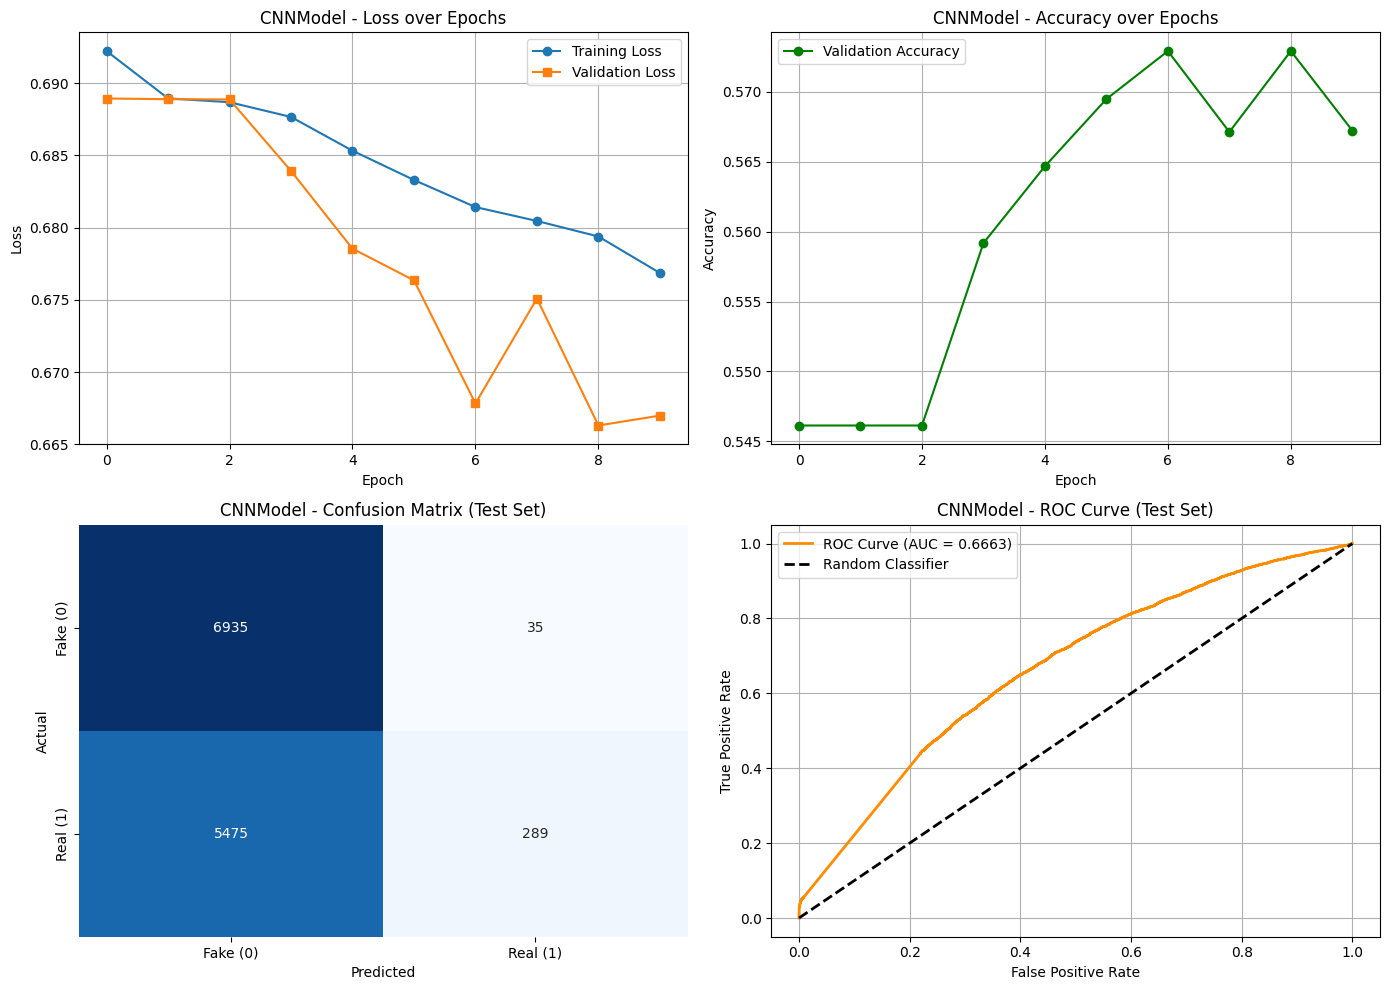


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.2091 | Val Loss: 0.1452 | Val Accuracy: 0.9427
Epoch [2/10] | Train Loss: 0.1507 | Val Loss: 0.1294 | Val Accuracy: 0.9509
Epoch [3/10] | Train Loss: 0.1329 | Val Loss: 0.1287 | Val Accuracy: 0.9497
Epoch [4/10] | Train Loss: 0.1211 | Val Loss: 0.1266 | Val Accuracy: 0.9516
Epoch [5/10] | Train Loss: 0.1098 | Val Loss: 0.1334 | Val Accuracy: 0.9507
Epoch [6/10] | Train Loss: 0.1024 | Val Loss: 0.1245 | Val Accuracy: 0.9542
Epoch [7/10] | Train Loss: 0.0950 | Val Loss: 0.1321 | Val Accuracy: 0.9532
Epoch [8/10] | Train Loss: 0.0844 | Val Loss: 0.1301 | Val Accuracy: 0.9550
Epoch [9/10] | Train Loss: 0.0804 | Val Loss: 0.1338 | Val Accuracy: 0.9537
Epoch [10/10] | Train Loss: 0.0756 | Val Loss: 0.1374 | Val Accuracy: 0.9544
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9540
Test AUC Score: 0.9895

Classification Report:
              precision    recall 

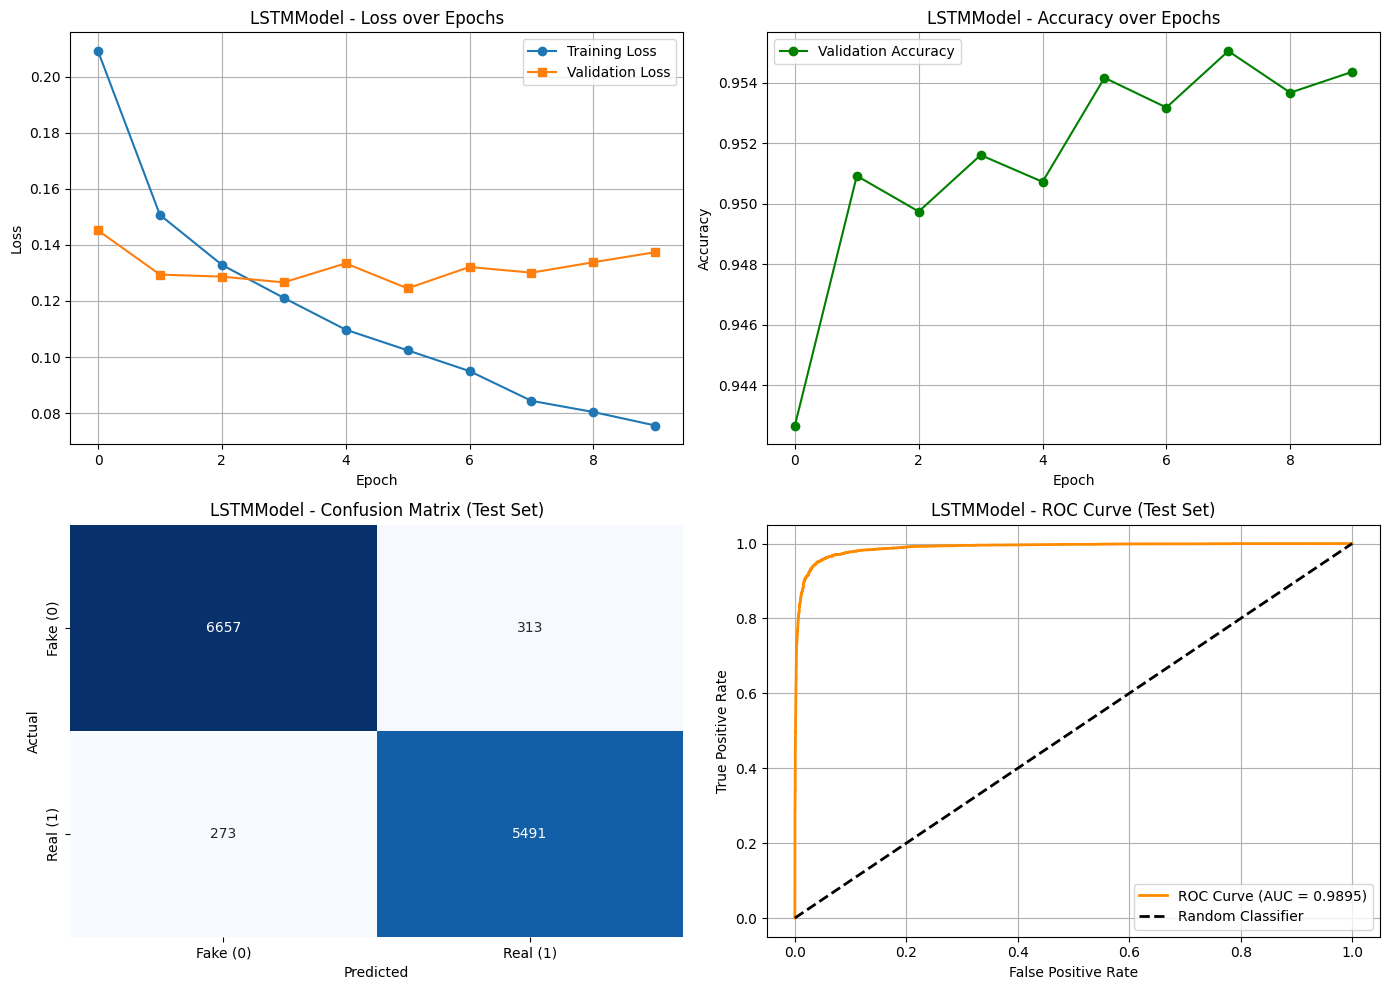


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6875 | Val Loss: 0.6758 | Val Accuracy: 0.5808
Epoch [2/10] | Train Loss: 0.6727 | Val Loss: 0.6567 | Val Accuracy: 0.6154
Epoch [3/10] | Train Loss: 0.6578 | Val Loss: 0.6415 | Val Accuracy: 0.6378
Epoch [4/10] | Train Loss: 0.6484 | Val Loss: 0.6332 | Val Accuracy: 0.6439
Epoch [5/10] | Train Loss: 0.6436 | Val Loss: 0.6378 | Val Accuracy: 0.6460
Epoch [6/10] | Train Loss: 0.6398 | Val Loss: 0.6243 | Val Accuracy: 0.6495
Epoch [7/10] | Train Loss: 0.6371 | Val Loss: 0.6226 | Val Accuracy: 0.6511
Epoch [8/10] | Train Loss: 0.6355 | Val Loss: 0.6193 | Val Accuracy: 0.6551
Epoch [9/10] | Train Loss: 0.6343 | Val Loss: 0.6230 | Val Accuracy: 0.6487
Epoch [10/10] | Train Loss: 0.6320 | Val Loss: 0.6218 | Val Accuracy: 0.6462
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6457
Test AUC Score: 0.7075

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.69      0.63   

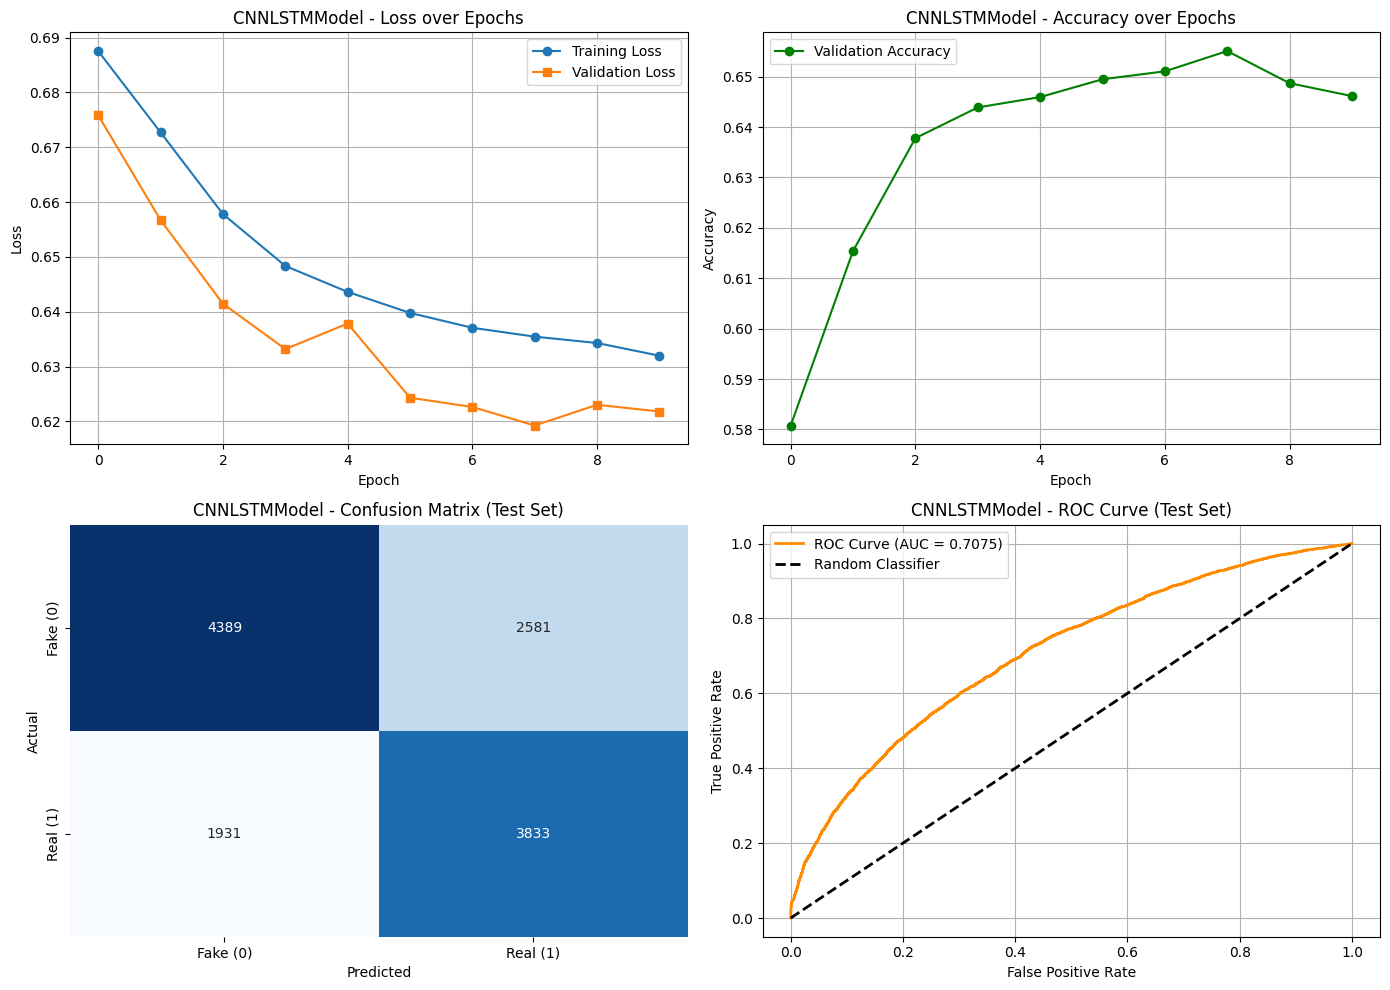


Pipeline completed successfully
Word2Vec feature size: 300 dimensions
Training samples: 50936
Test samples: 12734
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.5673
  - LSTM test accuracy: 0.9540
  - CNN-LSTM test accuracy: 0.6457



In [ ]:
# Run Word2Vec pipeline (set regenerate_features=False if you already have the CSV)
feature_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline_word2vec(
    dataset_csv_path='/content/drive/MyDrive/datasets/WELFake_processed.csv',
    vector_size=300,
    window=5,
    chunk_size=500,      # adjust as needed for memory
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
)


Starting Word2Vec + ML + DL pipeline

Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)
--------------------------------------------------------------------------------
Loading data from /content/drive/MyDrive/datasets/ISOT_processed.csv...
Training Word2Vec model...
Word2Vec model trained with vocabulary size: 60915
Features built in memory (not saved).

Step 2: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 39098
Total rows in train set: 31278
Total rows in test set: 7820

Class distribution in full dataset:
label
0    21196
1    17902
Name: count, dtype: int64

Class distribution in train set:
label
0    16992
1    14286
Name: count, dtype: int64

Class distribution in test set:
label
0    4204
1    3616
Name: count, dtype: int64

 KNN 


Step 3: Training traditional ML models
--------------------------------------------------------------------------------

 KNN 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:04:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4204
           1       0.98      0.96      0.97      3616

    accuracy                           0.97      7820
   macro avg       0.97      0.97      0.97      7820
weighted avg       0.97      0.97      0.97      7820


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4204
           1       0.96      0.92      0.94      3616

    accuracy                           0.95      7820
   macro avg       0.95      0.94      0.95      7820
weighted avg       0.95      0.95      0.95      7820


Step 4: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 31278
Test set size: 7820
Validation split: 20.0%
Effective training size: 25022
Effective validation size: 6255
✓ Test set wil

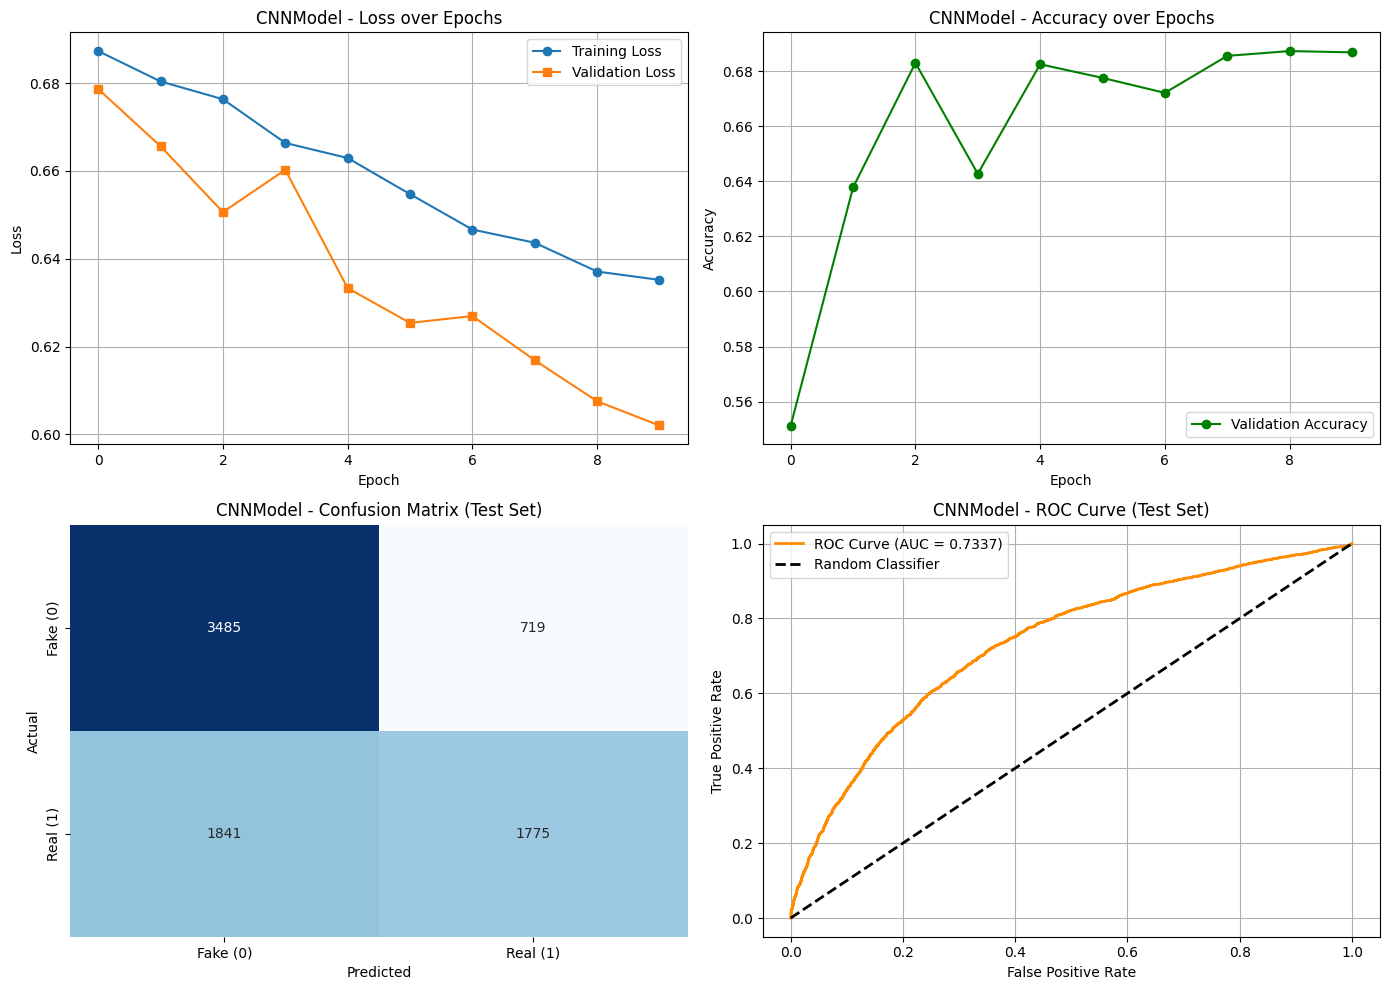


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.1098 | Val Loss: 0.0501 | Val Accuracy: 0.9827
Epoch [2/10] | Train Loss: 0.0490 | Val Loss: 0.0444 | Val Accuracy: 0.9850
Epoch [3/10] | Train Loss: 0.0357 | Val Loss: 0.0503 | Val Accuracy: 0.9826
Epoch [4/10] | Train Loss: 0.0309 | Val Loss: 0.0423 | Val Accuracy: 0.9863
Epoch [5/10] | Train Loss: 0.0276 | Val Loss: 0.0440 | Val Accuracy: 0.9869
Epoch [6/10] | Train Loss: 0.0247 | Val Loss: 0.0465 | Val Accuracy: 0.9875
Epoch [7/10] | Train Loss: 0.0215 | Val Loss: 0.0439 | Val Accuracy: 0.9877
Epoch [8/10] | Train Loss: 0.0199 | Val Loss: 0.0450 | Val Accuracy: 0.9872
Epoch [9/10] | Train Loss: 0.0192 | Val Loss: 0.0514 | Val Accuracy: 0.9874
Epoch [10/10] | Train Loss: 0.0169 | Val Loss: 0.0430 | Val Accuracy: 0.9869
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9875
Test AUC Score: 0.9988

Classification Report:
              precision    recall 

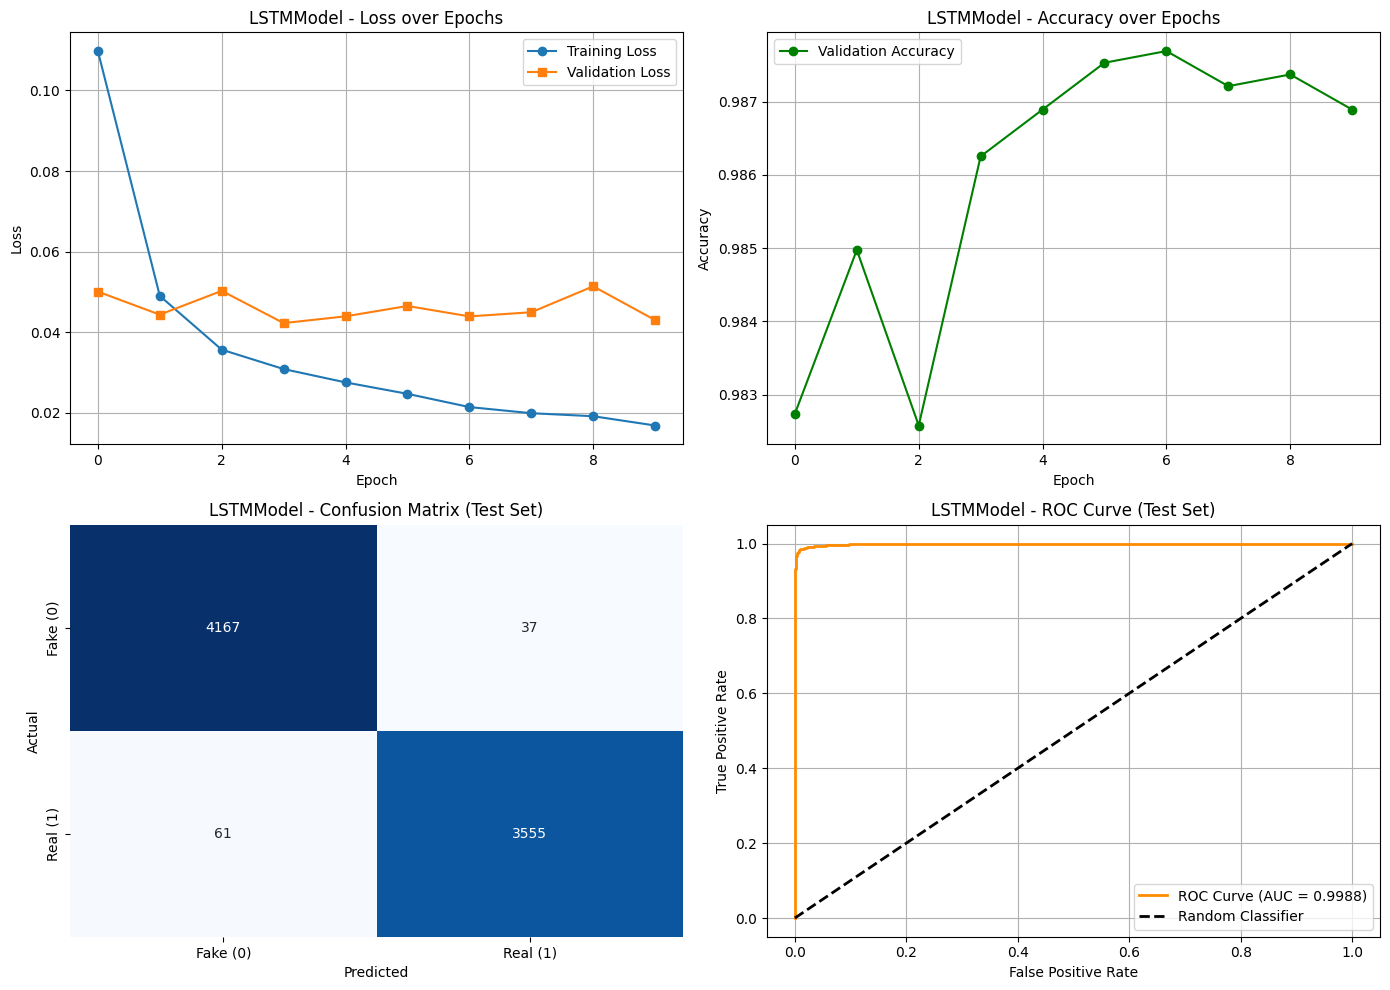


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6465 | Val Loss: 0.6156 | Val Accuracy: 0.6822
Epoch [2/10] | Train Loss: 0.6229 | Val Loss: 0.6075 | Val Accuracy: 0.6841
Epoch [3/10] | Train Loss: 0.6170 | Val Loss: 0.5995 | Val Accuracy: 0.6896
Epoch [4/10] | Train Loss: 0.6114 | Val Loss: 0.5941 | Val Accuracy: 0.6925
Epoch [5/10] | Train Loss: 0.6067 | Val Loss: 0.5847 | Val Accuracy: 0.6966
Epoch [6/10] | Train Loss: 0.6021 | Val Loss: 0.5833 | Val Accuracy: 0.6973
Epoch [7/10] | Train Loss: 0.5985 | Val Loss: 0.5783 | Val Accuracy: 0.7100
Epoch [8/10] | Train Loss: 0.5935 | Val Loss: 0.5804 | Val Accuracy: 0.7057
Epoch [9/10] | Train Loss: 0.5881 | Val Loss: 0.5763 | Val Accuracy: 0.7057
Epoch [10/10] | Train Loss: 0.5871 | Val Loss: 0.5685 | Val Accuracy: 0.7120
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.7005
Test AUC Score: 0.7675

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.69      0.79   

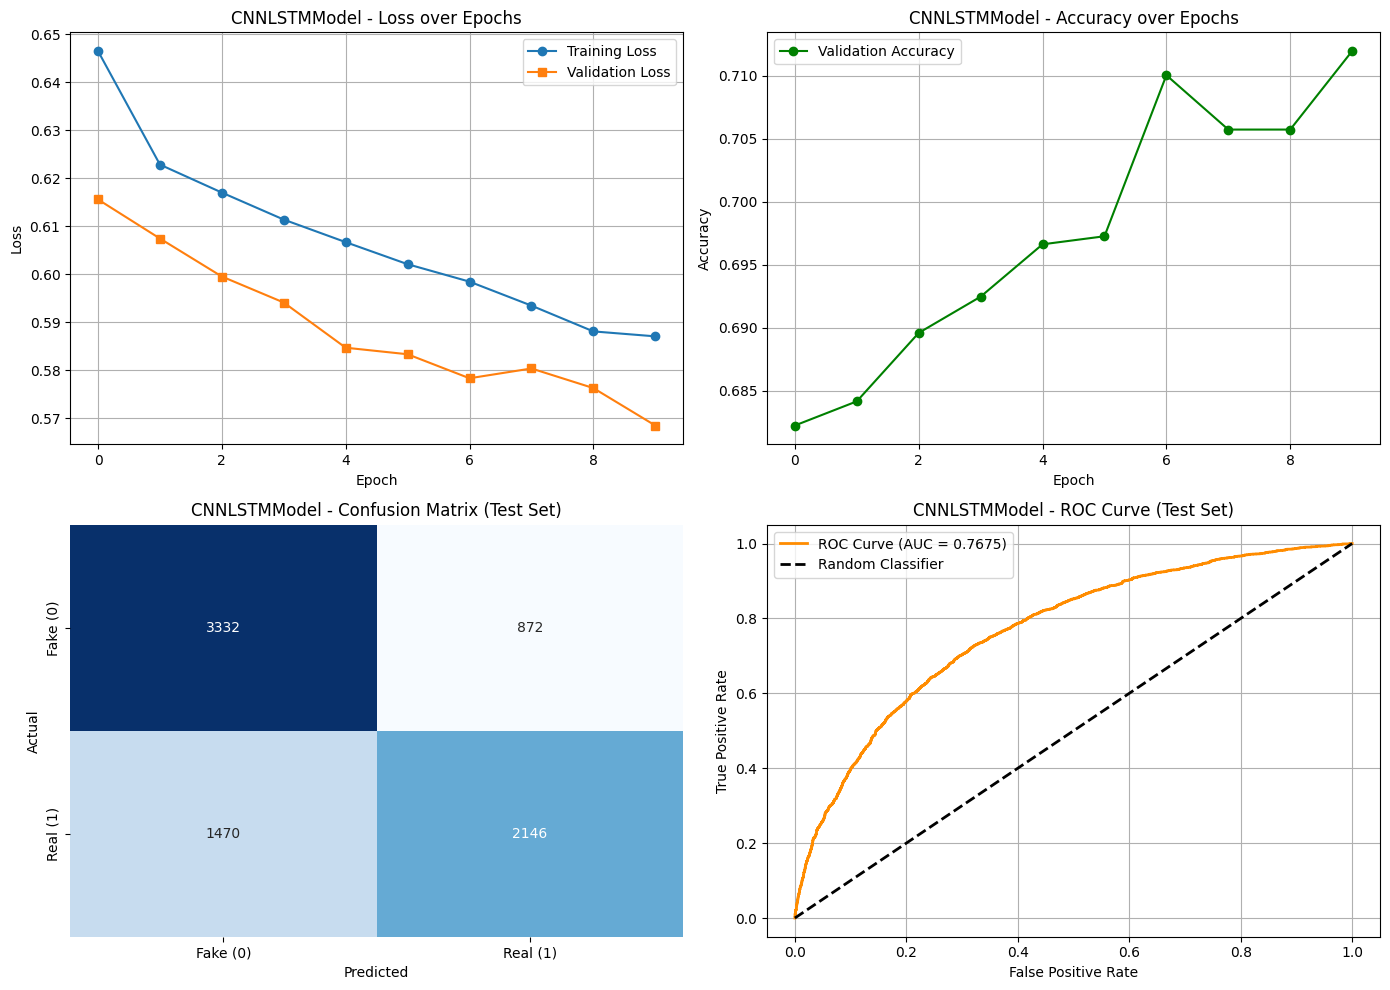


Pipeline completed successfully
Word2Vec feature size: 300 dimensions
Training samples: 31278
Test samples: 7820
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.6726
  - LSTM test accuracy: 0.9875
  - CNN-LSTM test accuracy: 0.7005



In [ ]:
#ISOT
feature_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline_word2vec(
    dataset_csv_path='/content/drive/MyDrive/datasets/ISOT_processed.csv',
    vector_size=300,
    window=5,
    chunk_size=500,      # adjust as needed for memory
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
)


Starting Word2Vec + ML + DL pipeline

Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)
--------------------------------------------------------------------------------
Loading data from /content/drive/MyDrive/datasets/Fake_News_Detection_processed.csv...
Training Word2Vec model...
Word2Vec model trained with vocabulary size: 60798
Features built in memory (not saved).

Step 2: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 38650
Total rows in train set: 30920
Total rows in test set: 7730

Class distribution in full dataset:
label
1    21194
0    17456
Name: count, dtype: int64

Class distribution in train set:
label
1    16971
0    13949
Name: count, dtype: int64

Class distribution in test set:
label
1    4223
0    3507
Name: count, dtype: int64

 KNN 


Step 3: Training traditional ML models
-------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:28:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3507
           1       0.97      0.99      0.98      4223

    accuracy                           0.98      7730
   macro avg       0.98      0.98      0.98      7730
weighted avg       0.98      0.98      0.98      7730


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      3507
           1       0.95      0.97      0.96      4223

    accuracy                           0.96      7730
   macro avg       0.96      0.96      0.96      7730
weighted avg       0.96      0.96      0.96      7730


Step 4: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 30920
Test set size: 7730
Validation split: 20.0%
Effective training size: 24736
Effective validation size: 6184
✓ Test set wil

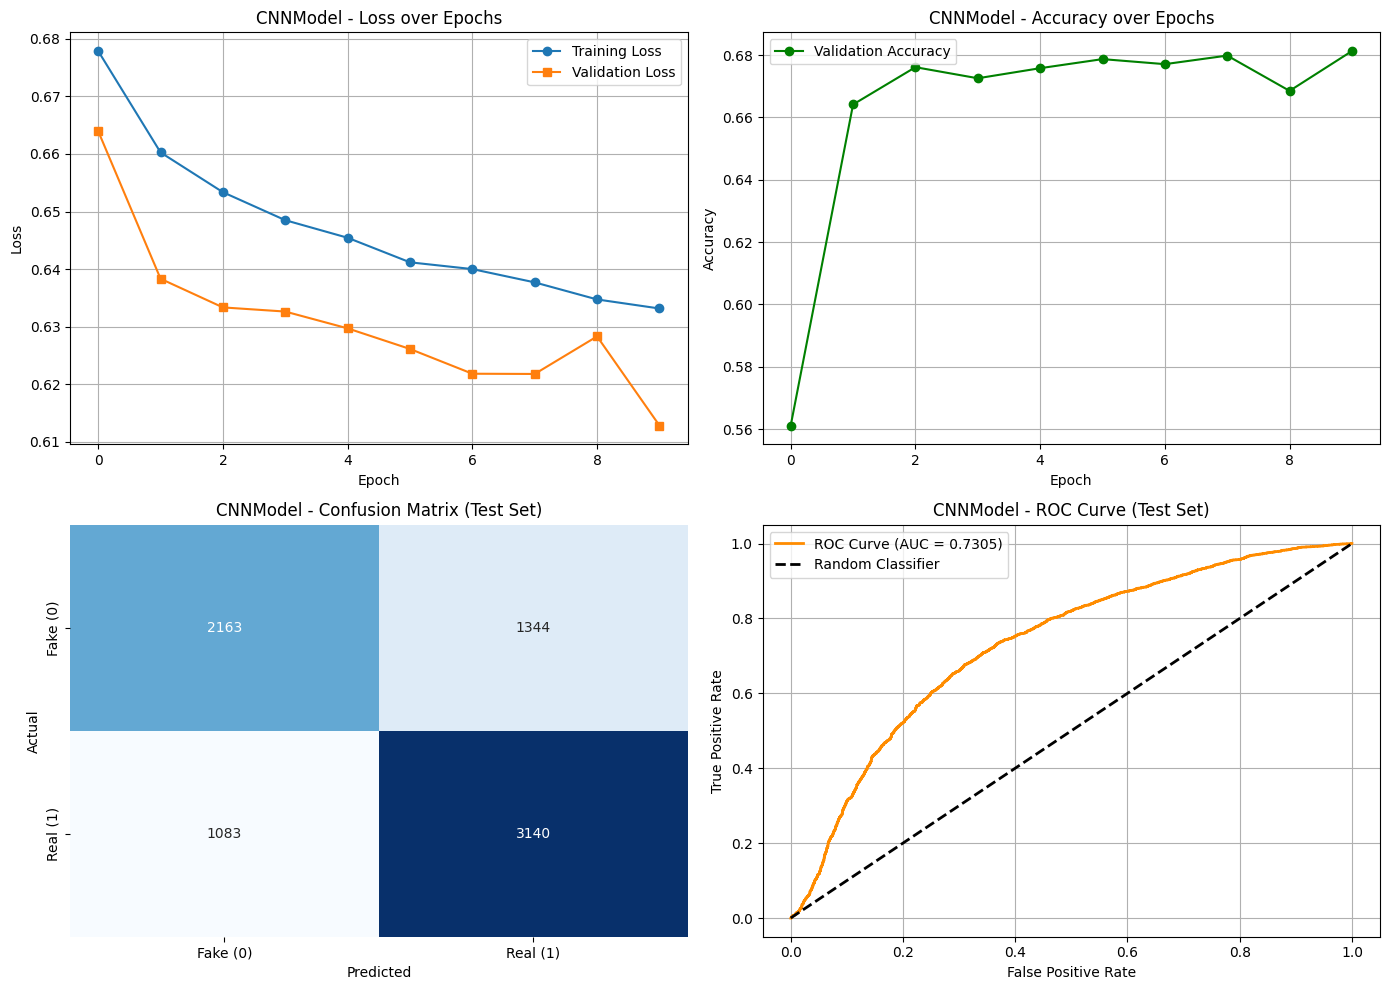


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.0962 | Val Loss: 0.0471 | Val Accuracy: 0.9838
Epoch [2/10] | Train Loss: 0.0438 | Val Loss: 0.0441 | Val Accuracy: 0.9851
Epoch [3/10] | Train Loss: 0.0347 | Val Loss: 0.0488 | Val Accuracy: 0.9854
Epoch [4/10] | Train Loss: 0.0300 | Val Loss: 0.0411 | Val Accuracy: 0.9872
Epoch [5/10] | Train Loss: 0.0260 | Val Loss: 0.0450 | Val Accuracy: 0.9871
Epoch [6/10] | Train Loss: 0.0237 | Val Loss: 0.0443 | Val Accuracy: 0.9882
Epoch [7/10] | Train Loss: 0.0209 | Val Loss: 0.0521 | Val Accuracy: 0.9875
Epoch [8/10] | Train Loss: 0.0185 | Val Loss: 0.0486 | Val Accuracy: 0.9866
Epoch [9/10] | Train Loss: 0.0184 | Val Loss: 0.0514 | Val Accuracy: 0.9859
Epoch [10/10] | Train Loss: 0.0154 | Val Loss: 0.0574 | Val Accuracy: 0.9877
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9893
Test AUC Score: 0.9993

Classification Report:
              precision    recall 

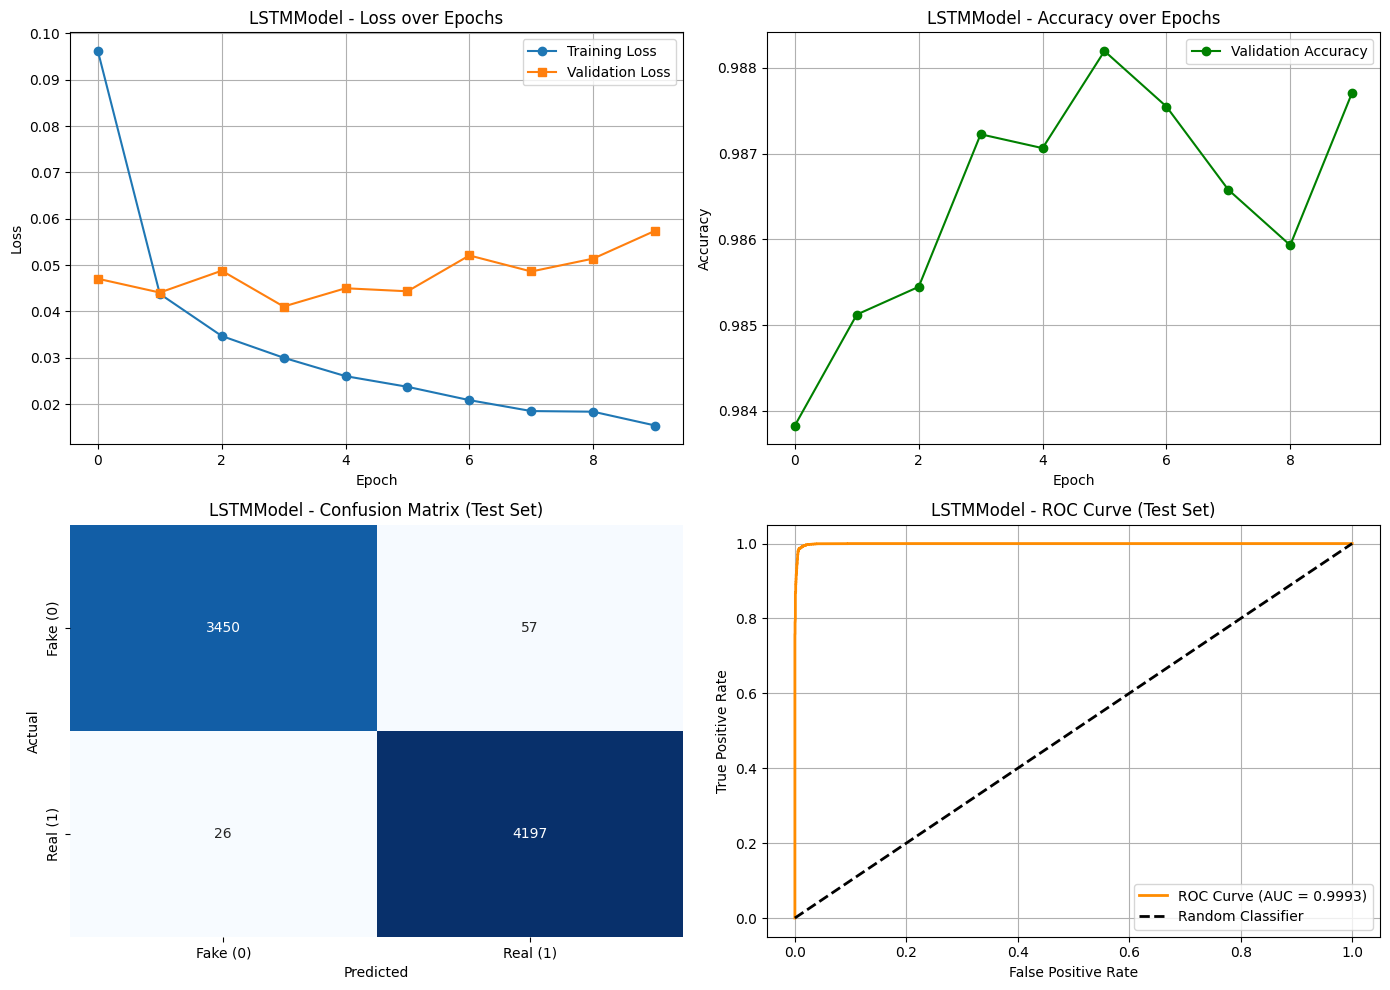


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6493 | Val Loss: 0.6399 | Val Accuracy: 0.6708
Epoch [2/10] | Train Loss: 0.6324 | Val Loss: 0.6233 | Val Accuracy: 0.6679
Epoch [3/10] | Train Loss: 0.6242 | Val Loss: 0.6116 | Val Accuracy: 0.6853
Epoch [4/10] | Train Loss: 0.6200 | Val Loss: 0.6100 | Val Accuracy: 0.6813
Epoch [5/10] | Train Loss: 0.6160 | Val Loss: 0.6020 | Val Accuracy: 0.6874
Epoch [6/10] | Train Loss: 0.6127 | Val Loss: 0.6013 | Val Accuracy: 0.6921
Epoch [7/10] | Train Loss: 0.6085 | Val Loss: 0.5971 | Val Accuracy: 0.6852
Epoch [8/10] | Train Loss: 0.6069 | Val Loss: 0.5925 | Val Accuracy: 0.6934
Epoch [9/10] | Train Loss: 0.6029 | Val Loss: 0.5855 | Val Accuracy: 0.6939
Epoch [10/10] | Train Loss: 0.5988 | Val Loss: 0.5963 | Val Accuracy: 0.6886
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6859
Test AUC Score: 0.7544

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.72      0.50   

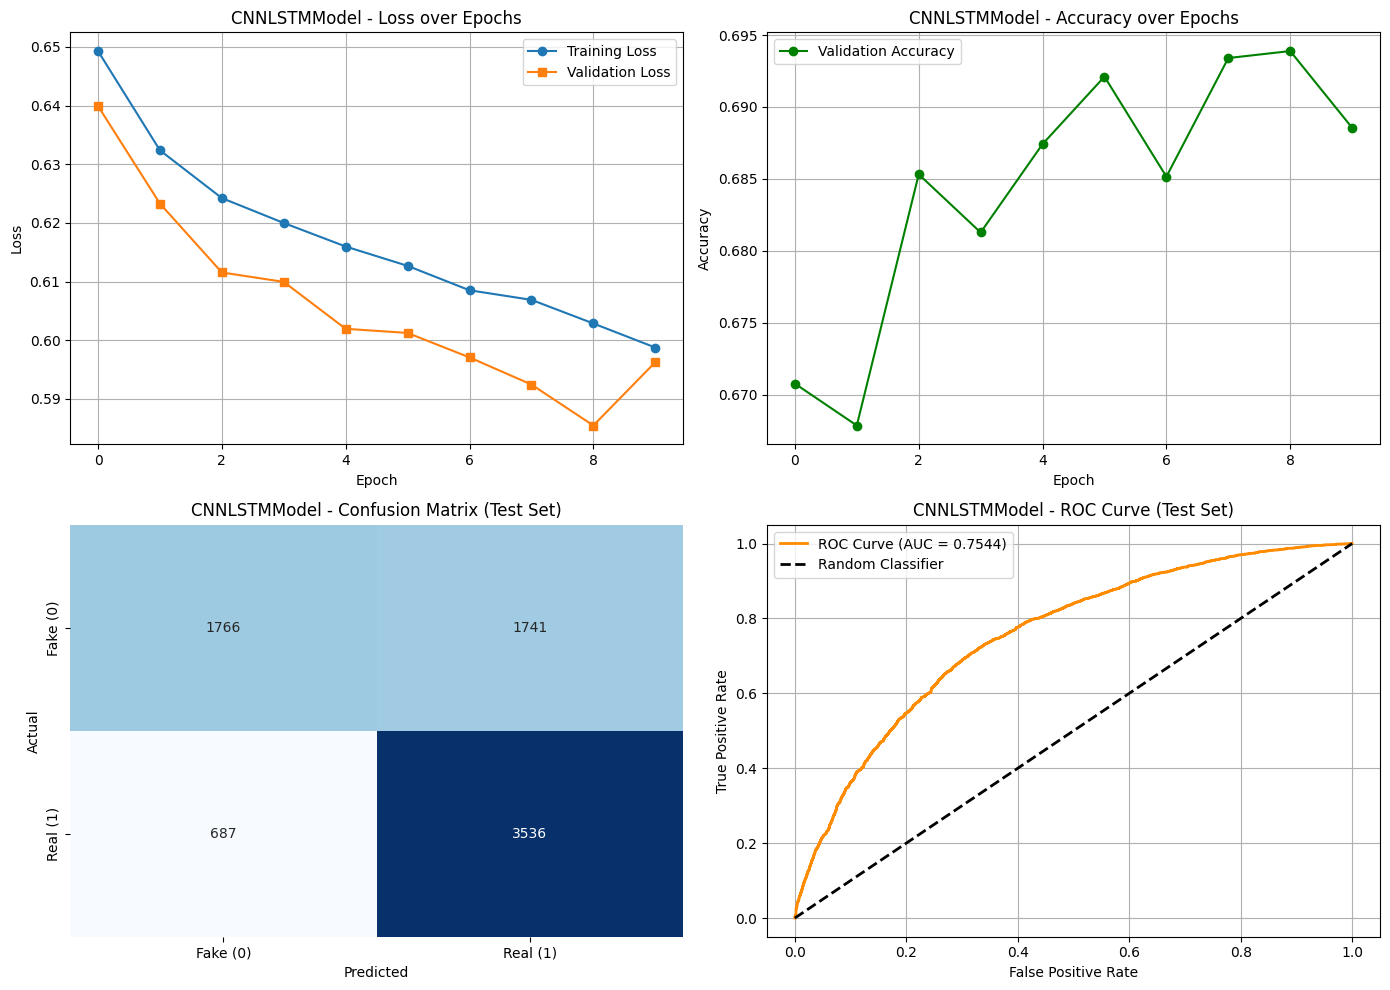


Pipeline completed successfully
Word2Vec feature size: 300 dimensions
Training samples: 30920
Test samples: 7730
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.6860
  - LSTM test accuracy: 0.9893
  - CNN-LSTM test accuracy: 0.6859



In [ ]:
#Fake news detection
feature_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline_word2vec(
    dataset_csv_path='/content/drive/MyDrive/datasets/Fake_News_Detection_processed.csv',
    vector_size=300,
    window=5,
    chunk_size=500,      # adjust as needed for memory
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
)


Starting Word2Vec + ML + DL pipeline

Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)
--------------------------------------------------------------------------------
Loading data from /content/drive/MyDrive/datasets/Fake_News_Classification_processed.csv...
Training Word2Vec model...
Word2Vec model trained with vocabulary size: 66789
Features built in memory (not saved).

Step 2: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 40580
Total rows in train set: 32464
Total rows in test set: 8116

Class distribution in full dataset:
label
1    21923
0    18657
Name: count, dtype: int64

Class distribution in train set:
label
1    17495
0    14969
Name: count, dtype: int64

Class distribution in test set:
label
1    4428
0    3688
Name: count, dtype: int64

 KNN 


Step 3: Training traditional ML models
--------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [02:43:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3688
           1       0.97      0.96      0.97      4428

    accuracy                           0.96      8116
   macro avg       0.96      0.96      0.96      8116
weighted avg       0.96      0.96      0.96      8116


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      3688
           1       0.95      0.95      0.95      4428

    accuracy                           0.94      8116
   macro avg       0.94      0.94      0.94      8116
weighted avg       0.94      0.94      0.94      8116


Step 4: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 32464
Test set size: 8116
Validation split: 20.0%
Effective training size: 25971
Effective validation size: 6492
✓ Test set wil

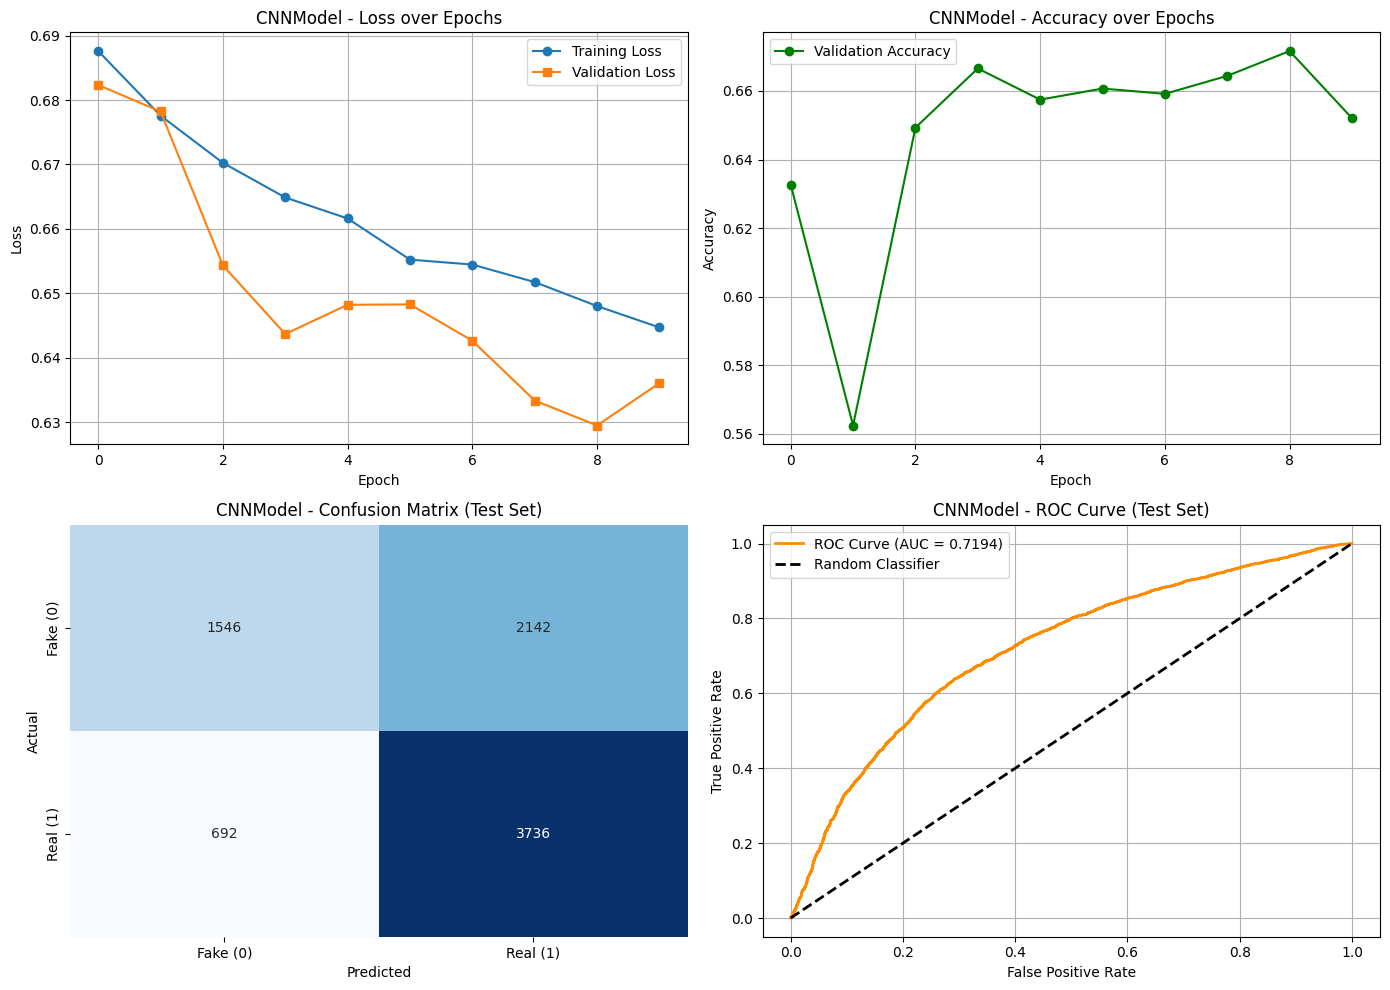


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.1362 | Val Loss: 0.0753 | Val Accuracy: 0.9741
Epoch [2/10] | Train Loss: 0.0775 | Val Loss: 0.0710 | Val Accuracy: 0.9747
Epoch [3/10] | Train Loss: 0.0653 | Val Loss: 0.0696 | Val Accuracy: 0.9751
Epoch [4/10] | Train Loss: 0.0582 | Val Loss: 0.0728 | Val Accuracy: 0.9755
Epoch [5/10] | Train Loss: 0.0499 | Val Loss: 0.0759 | Val Accuracy: 0.9740
Epoch [6/10] | Train Loss: 0.0476 | Val Loss: 0.0730 | Val Accuracy: 0.9761
Epoch [7/10] | Train Loss: 0.0395 | Val Loss: 0.0831 | Val Accuracy: 0.9726
Epoch [8/10] | Train Loss: 0.0384 | Val Loss: 0.0803 | Val Accuracy: 0.9732
Epoch [9/10] | Train Loss: 0.0348 | Val Loss: 0.0891 | Val Accuracy: 0.9741
Epoch [10/10] | Train Loss: 0.0346 | Val Loss: 0.0816 | Val Accuracy: 0.9747
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.9708
Test AUC Score: 0.9955

Classification Report:
              precision    recall 

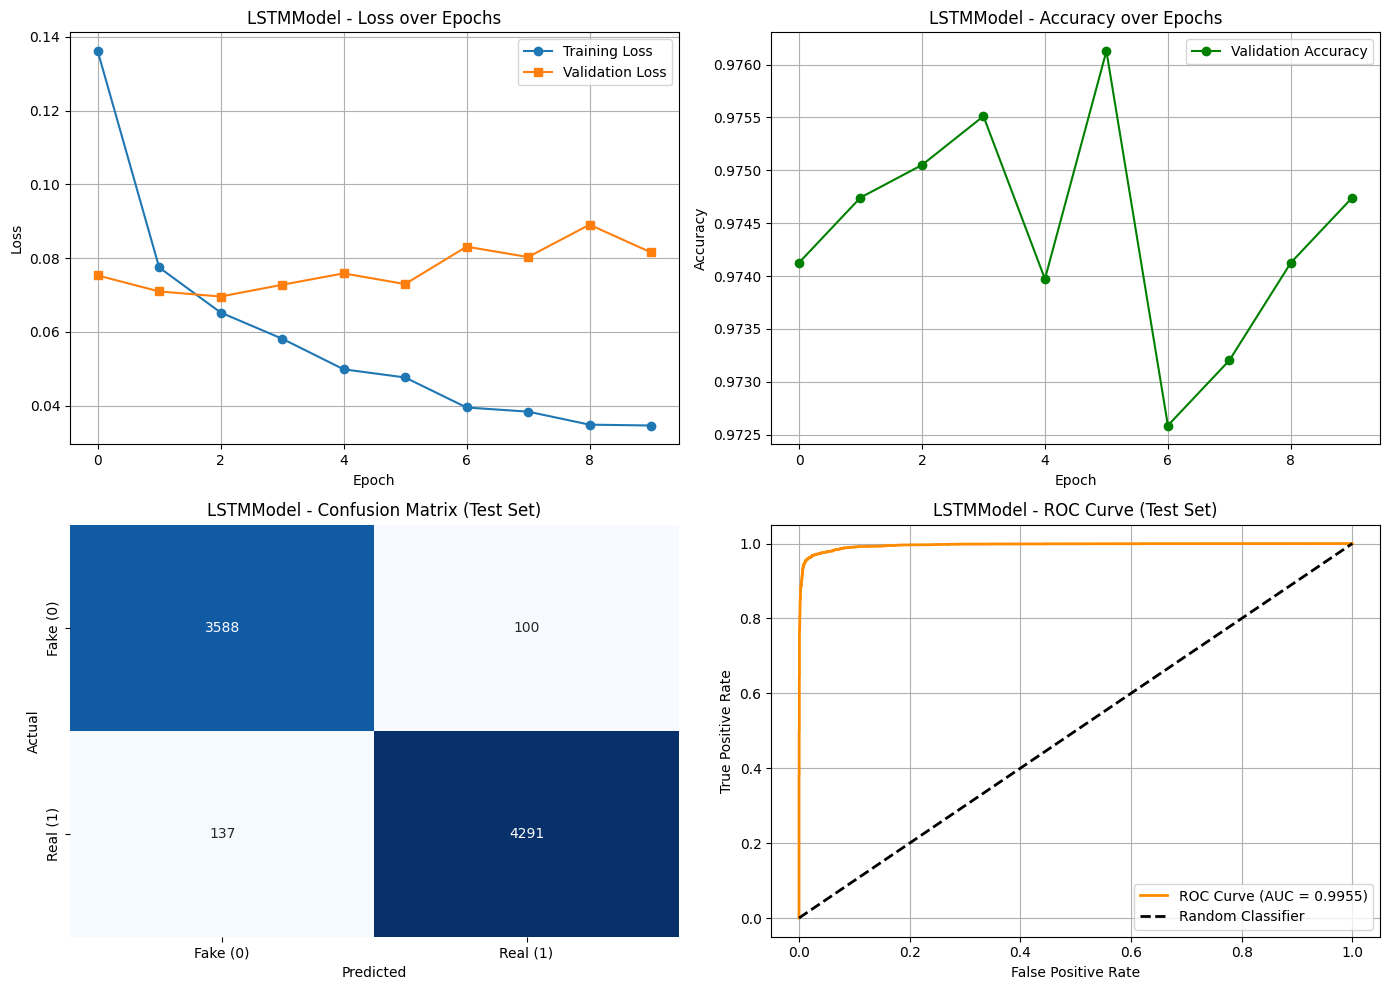


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6541 | Val Loss: 0.6354 | Val Accuracy: 0.6639
Epoch [2/10] | Train Loss: 0.6385 | Val Loss: 0.6334 | Val Accuracy: 0.6630
Epoch [3/10] | Train Loss: 0.6316 | Val Loss: 0.6226 | Val Accuracy: 0.6700
Epoch [4/10] | Train Loss: 0.6266 | Val Loss: 0.6210 | Val Accuracy: 0.6655
Epoch [5/10] | Train Loss: 0.6223 | Val Loss: 0.6268 | Val Accuracy: 0.6613
Epoch [6/10] | Train Loss: 0.6191 | Val Loss: 0.6082 | Val Accuracy: 0.6807
Epoch [7/10] | Train Loss: 0.6161 | Val Loss: 0.6018 | Val Accuracy: 0.6843
Epoch [8/10] | Train Loss: 0.6129 | Val Loss: 0.6031 | Val Accuracy: 0.6904
Epoch [9/10] | Train Loss: 0.6107 | Val Loss: 0.6012 | Val Accuracy: 0.6847
Epoch [10/10] | Train Loss: 0.6068 | Val Loss: 0.6028 | Val Accuracy: 0.6809
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.6827
Test AUC Score: 0.7470

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.71      0.51   

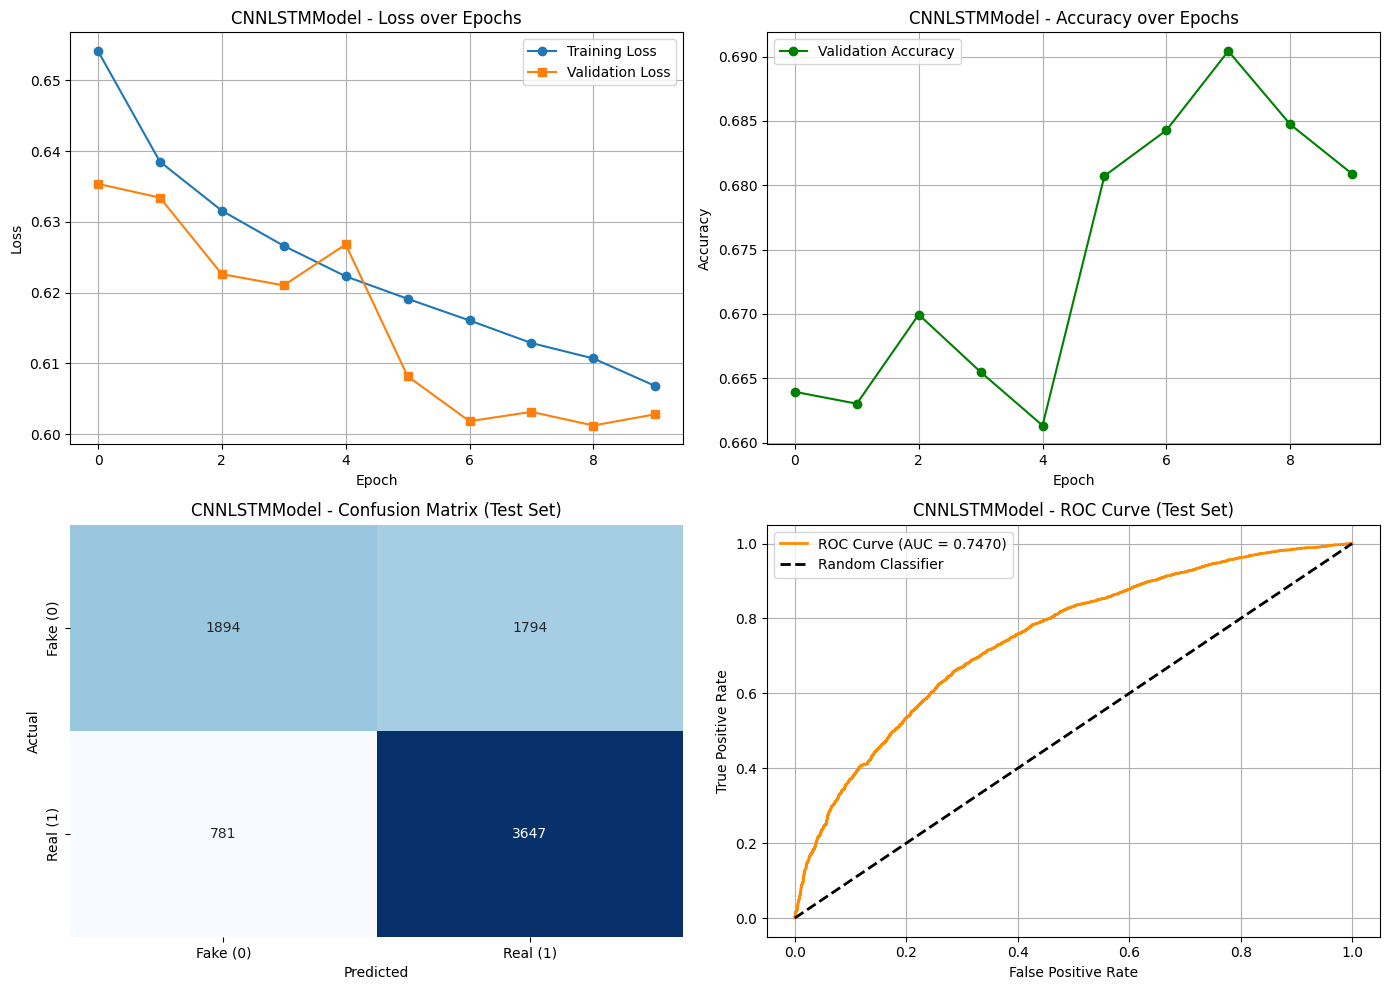


Pipeline completed successfully
Word2Vec feature size: 300 dimensions
Training samples: 32464
Test samples: 8116
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.6508
  - LSTM test accuracy: 0.9708
  - CNN-LSTM test accuracy: 0.6827



In [16]:
#Fake news classification
feature_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline_word2vec(
    dataset_csv_path="/content/drive/MyDrive/datasets/Fake_News_Classification_processed.csv",
    vector_size=300,
    window=5,
    chunk_size=500,      # adjust as needed for memory
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
)


Starting Word2Vec + ML + DL pipeline

Step 1: Training Word2Vec and creating features (in-memory, not saving CSV)
--------------------------------------------------------------------------------
Loading data from /content/drive/MyDrive/datasets/FakeNewsNet_processed.csv...
Training Word2Vec model...
Word2Vec model trained with vocabulary size: 9392
Features built in memory (not saved).

Step 2: Splitting dataset (80/20 train/test)
--------------------------------------------------------------------------------
Total rows in dataset: 21844
Total rows in train set: 17475
Total rows in test set: 4369

Class distribution in full dataset:
label
1    16522
0     5322
Name: count, dtype: int64

Class distribution in train set:
label
1    13182
0     4293
Name: count, dtype: int64

Class distribution in test set:
label
1    3340
0    1029
Name: count, dtype: int64

 KNN 


Step 3: Training traditional ML models
--------------------------------------------------------------------------------



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.70      0.46      0.56      1029
           1       0.85      0.94      0.89      3340

    accuracy                           0.83      4369
   macro avg       0.77      0.70      0.72      4369
weighted avg       0.81      0.83      0.81      4369


 Support Vector Classifier 

              precision    recall  f1-score   support

           0       0.76      0.42      0.54      1029
           1       0.84      0.96      0.90      3340

    accuracy                           0.83      4369
   macro avg       0.80      0.69      0.72      4369
weighted avg       0.82      0.83      0.81      4369


 XGBoost 



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [02:47:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.67      0.47      0.55      1029
           1       0.85      0.93      0.89      3340

    accuracy                           0.82      4369
   macro avg       0.76      0.70      0.72      4369
weighted avg       0.81      0.82      0.81      4369


 Random Forest Classifier 

              precision    recall  f1-score   support

           0       0.70      0.38      0.49      1029
           1       0.83      0.95      0.89      3340

    accuracy                           0.82      4369
   macro avg       0.76      0.67      0.69      4369
weighted avg       0.80      0.82      0.79      4369


Step 4: Training deep learning models with validation/test split
--------------------------------------------------------------------------------
DATA SPLIT VERIFICATION
Training set size: 17475
Test set size: 4369
Validation split: 20.0%
Effective training size: 13980
Effective validation size: 3495
✓ Test set wil

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


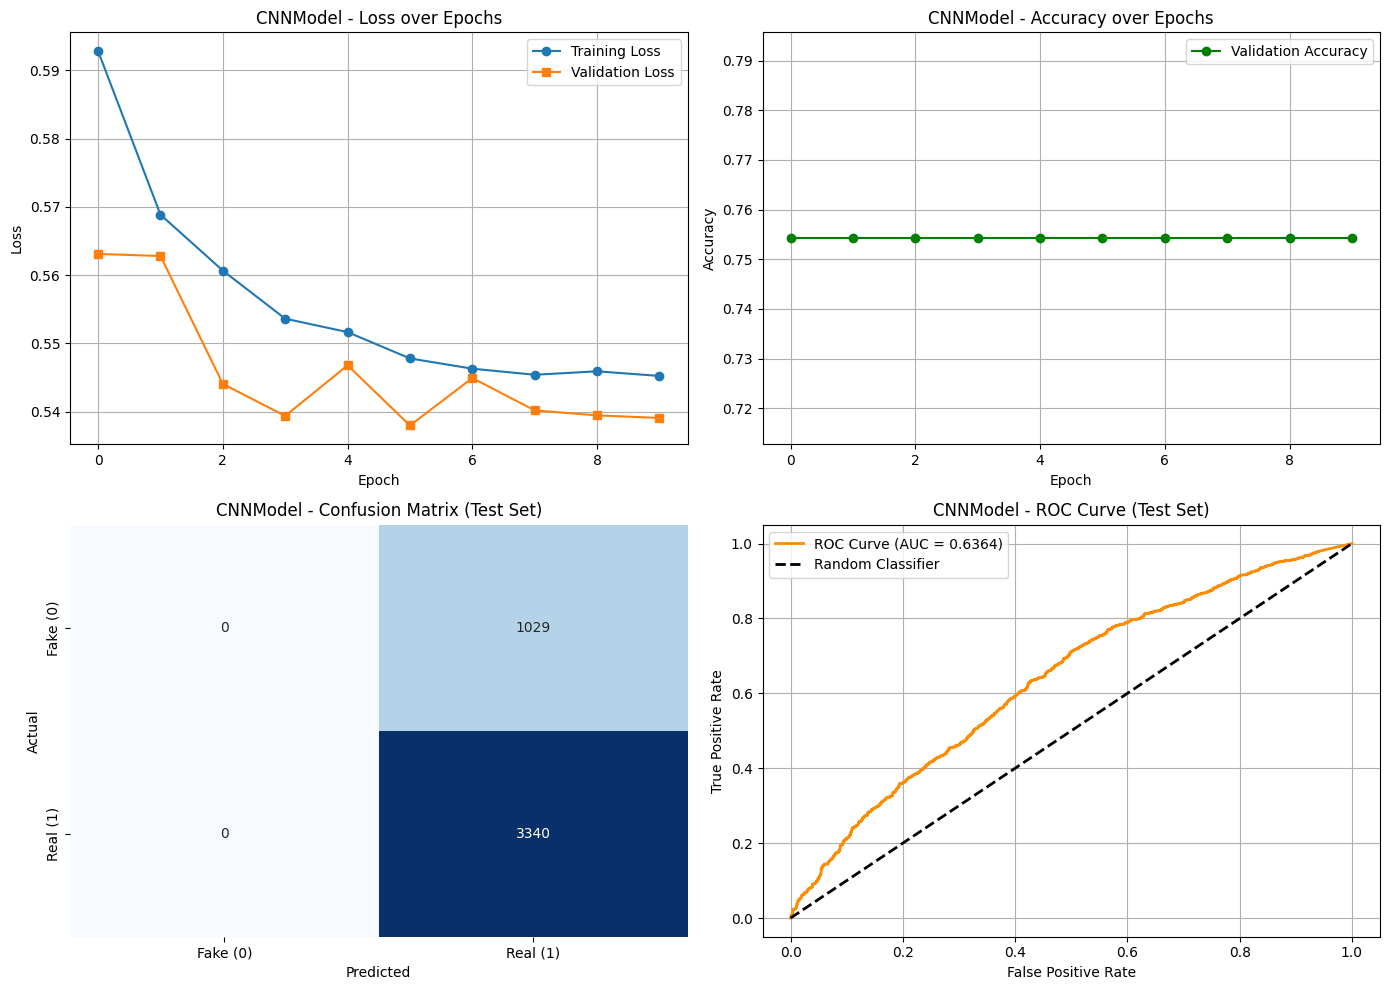


TRAINING LSTM MODEL
Training on device: cuda
Model: LSTMModel
Epoch [1/10] | Train Loss: 0.4486 | Val Loss: 0.3993 | Val Accuracy: 0.8303
Epoch [2/10] | Train Loss: 0.3984 | Val Loss: 0.3990 | Val Accuracy: 0.8240
Epoch [3/10] | Train Loss: 0.3870 | Val Loss: 0.3982 | Val Accuracy: 0.8252
Epoch [4/10] | Train Loss: 0.3672 | Val Loss: 0.4037 | Val Accuracy: 0.8252
Epoch [5/10] | Train Loss: 0.3549 | Val Loss: 0.3972 | Val Accuracy: 0.8246
Epoch [6/10] | Train Loss: 0.3434 | Val Loss: 0.3981 | Val Accuracy: 0.8263
Epoch [7/10] | Train Loss: 0.3303 | Val Loss: 0.4117 | Val Accuracy: 0.8289
Epoch [8/10] | Train Loss: 0.3181 | Val Loss: 0.4124 | Val Accuracy: 0.8266
Epoch [9/10] | Train Loss: 0.3072 | Val Loss: 0.4199 | Val Accuracy: 0.8269
Epoch [10/10] | Train Loss: 0.2964 | Val Loss: 0.4423 | Val Accuracy: 0.8289
LSTMModel training completed!

FINAL EVALUATION ON TEST SET - LSTMModel

Test Accuracy: 0.8260
Test AUC Score: 0.8389

Classification Report:
              precision    recall 

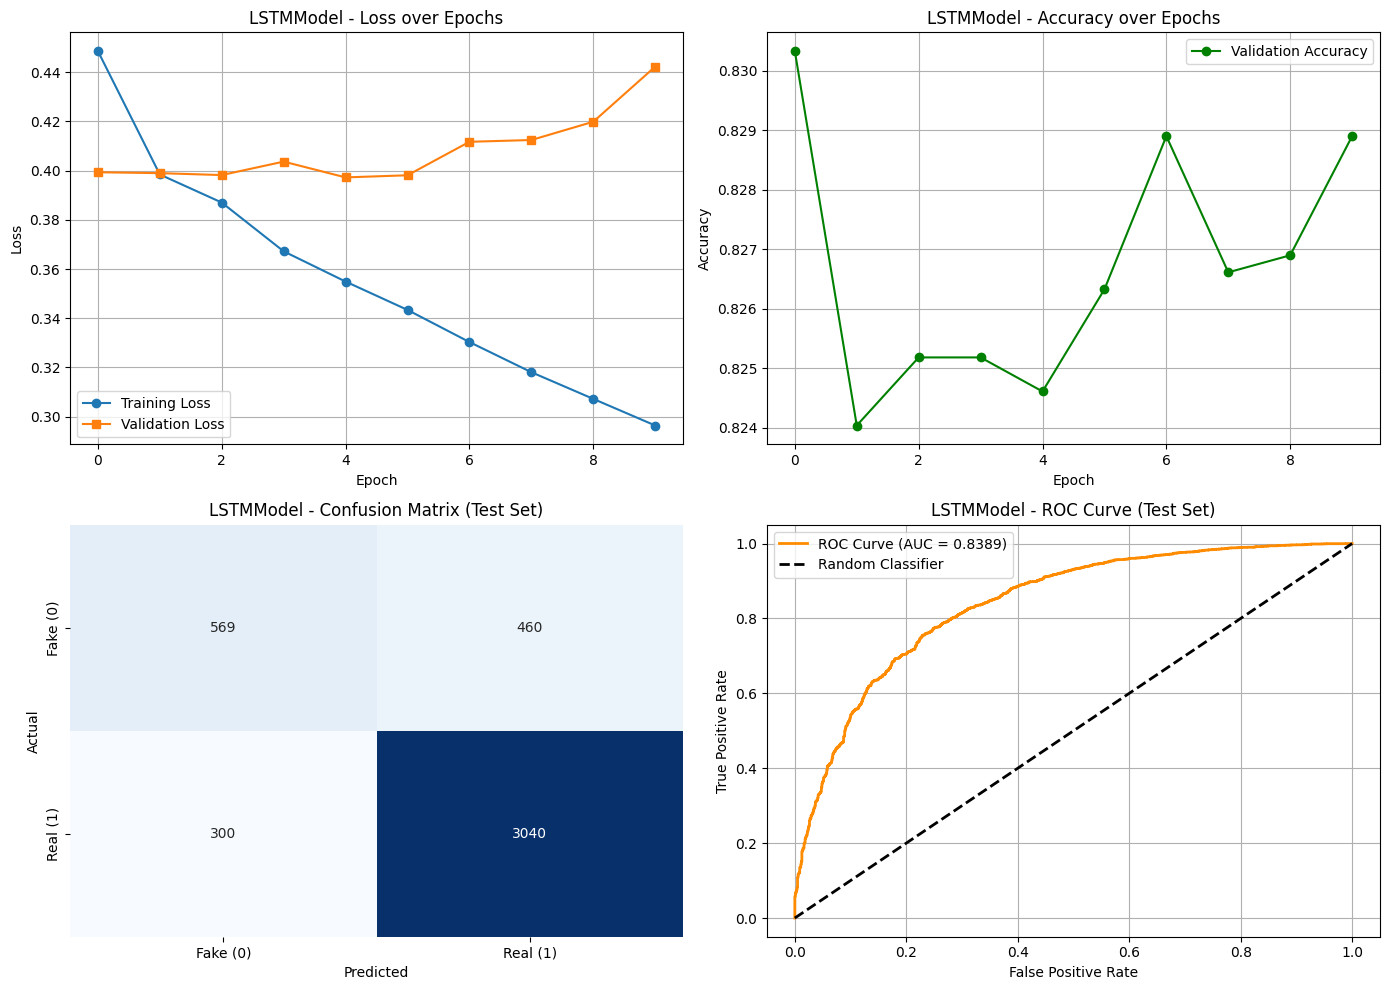


TRAINING CNN-LSTM HYBRID MODEL
Training on device: cuda
Model: CNNLSTMModel


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/10] | Train Loss: 0.5664 | Val Loss: 0.5449 | Val Accuracy: 0.7542
Epoch [2/10] | Train Loss: 0.5544 | Val Loss: 0.5451 | Val Accuracy: 0.7542
Epoch [3/10] | Train Loss: 0.5506 | Val Loss: 0.5407 | Val Accuracy: 0.7542
Epoch [4/10] | Train Loss: 0.5475 | Val Loss: 0.5370 | Val Accuracy: 0.7542
Epoch [5/10] | Train Loss: 0.5440 | Val Loss: 0.5414 | Val Accuracy: 0.7542
Epoch [6/10] | Train Loss: 0.5454 | Val Loss: 0.5401 | Val Accuracy: 0.7542
Epoch [7/10] | Train Loss: 0.5423 | Val Loss: 0.5360 | Val Accuracy: 0.7542
Epoch [8/10] | Train Loss: 0.5424 | Val Loss: 0.5391 | Val Accuracy: 0.7542
Epoch [9/10] | Train Loss: 0.5407 | Val Loss: 0.5361 | Val Accuracy: 0.7542
Epoch [10/10] | Train Loss: 0.5418 | Val Loss: 0.5343 | Val Accuracy: 0.7542
CNNLSTMModel training completed!

FINAL EVALUATION ON TEST SET - CNNLSTMModel

Test Accuracy: 0.7645
Test AUC Score: 0.6388

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


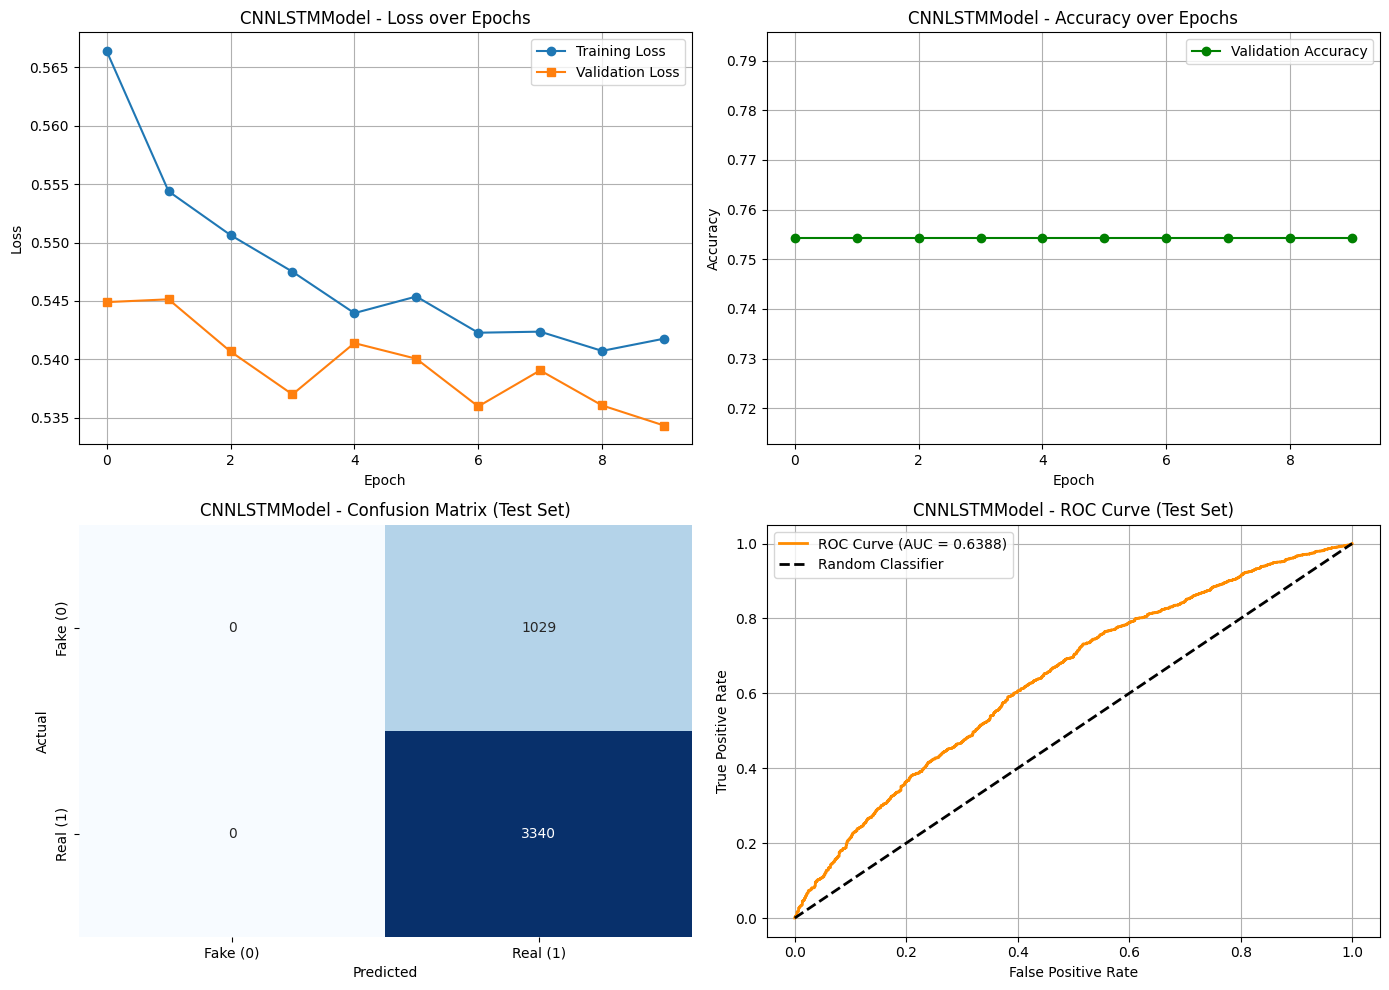


Pipeline completed successfully
Word2Vec feature size: 300 dimensions
Training samples: 17475
Test samples: 4369
ML models trained (KNN, Naive Bayes, Logistic Regression, SVC, XGBoost, Random Forest)
DL models trained (CNN, LSTM, CNN-LSTM)
  - CNN test accuracy: 0.7645
  - LSTM test accuracy: 0.8260
  - CNN-LSTM test accuracy: 0.7645



In [17]:
#FakeNewsNet
feature_df, xtrain, ytrain, xtest, ytest, models_history = run_complete_pipeline_word2vec(
    dataset_csv_path='/content/drive/MyDrive/datasets/FakeNewsNet_processed.csv',
    vector_size=300,
    window=5,
    chunk_size=500,      # adjust as needed for memory
    regenerate_features=True,
    train_ml=True,
    train_dl=True,
    dl_epochs=10,
    dl_batch_size=32,
    val_split=0.2,
)